# FluxTransformer: A Neural Surrogate for Metabolic Flux Prediction

This notebook implements *FluxTransformer*, a neural surrogate model designed to predict flux distributions in the *E. coli core* metabolic network. The model uses a Transformer-based architecture with multi-head attention and feedforward layers to approximate the results of Flux Balance Analysis (FBA) from extracellular metabolite uptake rates.

The notebook includes:

* Data preprocessing and preparation

* Model architecture implemented in PyTorch

* Training and evaluation on simulated flux datasets

* Systematic testing of multiple Transformer model configurations to assess performance

In [ ]:
import os
import random
import time
import gc

import numpy as np
import pandas as pd
from IPython.display import display
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
pd.set_option('display.max_rows', None)

In [2]:
DATA_PATH = "./data/2025-07-15_full_training_data_98066_samples.csv" # carbons log-uniform, others uniform
#DATA_PATH = "./data/2025-07-24_full_training_data_49014_samples.csv" # carbons log-uniform, others uniform
#DATA_PATH = "./data/2025-07-22_full_training_data_29446_samples.csv" # carbons log-uniform, others uniform
#DATA_PATH = "./data/2025-07-22_full_training_data_19637_samples.csv" # carbons log-uniform, others uniform
#DATA_PATH = "./data/2025-07-22_full_training_data_9844_samples.csv" # carbons log-uniform, others uniform
#DATA_PATH = "./data/2025-07-15_full_training_data_99518_easy_samples.csv" #log-uniform samples

In [3]:
# Set all random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

In [4]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

print(f"PyTorch version: {torch.__version__}")

Training on device: cuda
PyTorch version: 2.5.1+cu121


In [5]:
def print_gpu_memory():
    """
    Displays the current GPU memory usage by PyTorch on the active CUDA device.
    Useful for monitoring GPU memory usage during training.
    """
    if torch.cuda.is_available():
        device = torch.cuda.current_device()
        allocated = torch.cuda.memory_allocated(device) / 1024**2
        reserved = torch.cuda.memory_reserved(device) / 1024**2
        print(f'Allocated memory: {allocated:.2f} MB')
        print(f'Reserved memory: {reserved:.2f} MB')
    else:
        print("CUDA is not available.")

In [ ]:
class AttentionBlock(nn.Module):
    """Custom multi-head attention block for metabolic modeling"""
    def __init__(self, d_model=8, n_heads=2, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)
        x_norm = self.layer_norm(x) # pre-norm
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True, average_attn_weights=False)

        x_out = attn_out + x

        # Per-head diffusion of c:
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)  # (1,H,1,1)
        c_att = (c_heads * alpha).sum(dim=1)  # (B, S, 1)

        c_out = c_att + c

        return x_out, c_out

In [ ]:
# pre-norm

class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [8]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=8, n_heads=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c

In [9]:
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=115,
        d_model=8,
        n_heads=2,
        n_layers=2,
        d_ff=128,
        dropout=0.1
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        
        self.input_embedding = nn.Embedding(vocab_size, d_model)
        
        self.layers = nn.ModuleList([
            FluxTransformerLayer(
                d_model=d_model,
                n_heads=n_heads,
                d_ff=d_ff,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

    def forward(self, c):
        batch_size = c.size(0)
        
        # Create token indices once
        y = torch.arange(self.vocab_size, device=c.device)
        y = y.unsqueeze(0).expand(batch_size, -1)  # (batch, seq)
        
        # Embed tokens once
        x = self.input_embedding(y)  # (batch, seq, d_model)
        
        for layer in self.layers:
            x, c = layer(x, c)
        
        return c

In [10]:
def load_data(filepath):
    """Load and preprocess the training data"""
    inputs = [
        'EX_glc__D_e', 'EX_fru_e', 'EX_lac__D_e', 'EX_pyr_e', 'EX_ac_e',
        'EX_akg_e', 'EX_succ_e', 'EX_fum_e', 'EX_mal__L_e', 'EX_etoh_e',
        'EX_acald_e', 'EX_for_e', 'EX_gln__L_e', 'EX_glu__L_e',
        'EX_co2_e', 'EX_h_e', 'EX_h2o_e', 'EX_nh4_e', 'EX_o2_e', 'EX_pi_e'
    ]

    outputs = [
        'ACALD_flux', 'ACALDt_flux', 'ACKr_flux', 'ACONTa_flux', 'ACONTb_flux',
        'ACt2r_flux', 'ADK1_flux', 'AKGDH_flux', 'AKGt2r_flux', 'ALCD2x_flux',
        'ATPM_flux', 'ATPS4r_flux', 'Biomass_Ecoli_core_flux', 'CO2t_flux', 'CS_flux',
        'CYTBD_flux', 'D_LACt2_flux', 'ENO_flux', 'ETOHt2r_flux', 'EX_ac_e_flux',
        'EX_acald_e_flux', 'EX_akg_e_flux', 'EX_co2_e_flux', 'EX_etoh_e_flux', 'EX_for_e_flux',
        'EX_fru_e_flux', 'EX_fum_e_flux', 'EX_glc__D_e_flux', 'EX_gln__L_e_flux', 'EX_glu__L_e_flux',
        'EX_h_e_flux', 'EX_h2o_e_flux', 'EX_lac__D_e_flux', 'EX_mal__L_e_flux', 'EX_nh4_e_flux',
        'EX_o2_e_flux', 'EX_pi_e_flux', 'EX_pyr_e_flux', 'EX_succ_e_flux', 'FBA_flux',
        'FBP_flux', 'FORt2_flux', 'FORti_flux', 'FRD7_flux', 'FRUpts2_flux',
        'FUM_flux', 'FUMt2_2_flux', 'G6PDH2r_flux', 'GAPD_flux', 'GLCpts_flux',
        'GLNS_flux', 'GLNabc_flux', 'GLUDy_flux', 'GLUN_flux', 'GLUSy_flux',
        'GLUt2r_flux', 'GND_flux', 'H2Ot_flux', 'ICDHyr_flux', 'ICL_flux',
        'LDH_D_flux', 'MALS_flux', 'MALt2_2_flux', 'MDH_flux', 'ME1_flux',
        'ME2_flux', 'NADH16_flux', 'NADTRHD_flux', 'NH4t_flux', 'O2t_flux',
        'PDH_flux', 'PFK_flux', 'PFL_flux', 'PGI_flux', 'PGK_flux',
        'PGL_flux', 'PGM_flux', 'PIt2r_flux', 'PPC_flux', 'PPCK_flux',
        'PPS_flux', 'PTAr_flux', 'PYK_flux', 'PYRt2_flux', 'RPE_flux',
        'RPI_flux', 'SUCCt2_2_flux', 'SUCCt3_flux', 'SUCDi_flux', 'SUCOAS_flux',
        'TALA_flux', 'THD2_flux', 'TKT1_flux', 'TKT2_flux', 'TPI_flux'
    ]
    
    df = pd.read_csv(filepath)

    # Fill missing inputs with 0 (i.e., not uptaken)
    df[inputs] = df[inputs].fillna(0)

    print(f"\nLoaded data with {len(df)} samples from {filepath}")
    print(f"Number of input features: {len(inputs)}")
    print(f"Number of output targets: {len(outputs)}")

    X = df[inputs].to_numpy(dtype=np.float32)
    y = df[outputs].to_numpy(dtype=np.float32)

    X_combined = np.hstack([X, np.zeros_like(y)])
    y_combined = np.hstack([np.zeros_like(X), y])

    return X_combined, y_combined, inputs, outputs

In [11]:
def prepare_tensors(X, y, test_size=0.4, device="cpu"):
    """
    Split data into train/test and convert to PyTorch tensors.
    
    Parameters:
        X (ndarray): Input features.
        y (ndarray): Output targets.
        test_size (float): Fraction of data to reserve for testing.
        device (str or torch.device): Device to move tensors to.
    
    Returns:
        X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor (torch.Tensor)
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    # Optional: standardize inputs (only input features, i.e., first 20 columns)
    # scaler = StandardScaler()
    # X_train[:, :20] = scaler.fit_transform(X_train[:, :20])
    # X_test[:, :20] = scaler.transform(X_test[:, :20])

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor

In [12]:
def create_dataloaders(X_train, y_train, X_test, y_test, batch_size):
    """
    Create PyTorch DataLoaders for training and testing.

    Parameters:
        X_train, y_train (Tensor): Training data and labels.
        X_test, y_test (Tensor): Test data and labels.
        batch_size (int): Batch size for loading.

    Returns:
        train_loader, test_loader (DataLoader): PyTorch DataLoaders.
    """
    train_dataset = TensorDataset(X_train.unsqueeze(-1), y_train.unsqueeze(-1))
    test_dataset = TensorDataset(X_test.unsqueeze(-1), y_test.unsqueeze(-1))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

In [13]:
# Load and preprocess data

X, y, input_cols, output_cols = load_data(DATA_PATH)
X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)
train_loader, test_loader = create_dataloaders(X_train, y_train, X_test, y_test, batch_size=128)


Loaded data with 98066 samples from ./data/2025-07-15_full_training_data_98066_samples.csv
Number of input features: 20
Number of output targets: 95
Training samples: 58839
Test samples: 39227


In [14]:
X_train.size(), y_train.size()

(torch.Size([58839, 115]), torch.Size([58839, 115]))

In [15]:
def train_model(d_model=8, n_heads=2, n_layers=2, d_ff=128, num_epochs=1000, learning_rate=0.001, dropout=0.1):
    start_time = time.time()

    model = FluxTransformer(
        vocab_size=115,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    #optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    #criterion = nn.MSELoss()
    criterion = nn.HuberLoss()

    train_losses = []
    test_losses = []

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * batch_X.size(0)

            # Explicitly free tensors
            del predictions, loss
            torch.cuda.empty_cache()
        
        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Evaluation
        model.eval()
        epoch_test_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                epoch_test_loss += loss.item() * batch_X.size(0)

                # Explicitly free tensors
                del predictions, loss
                torch.cuda.empty_cache()
        
        epoch_test_loss /= len(test_loader.dataset)
        test_losses.append(epoch_test_loss)

        if (epoch+1) % 100 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {epoch_train_loss:.6f} | "
                f"Test Loss: {epoch_test_loss:.6f}")
        
        # Additional memory cleanup after epoch
        torch.cuda.empty_cache()
        gc.collect()

    print('Training Completed.')
    end_time = time.time()
    elapsed_time = end_time - start_time
    mins, secs = divmod(elapsed_time, 60)
    print(f"Training took {int(mins)} min {secs:.1f} sec.")
    
    return train_losses, test_losses, model

### Plotting Functions

In [16]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [17]:
def plot_diagnostics_2x2(y_true, y_pred, label):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples"""
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()
    plt.close()

In [18]:
def plot_prediction_sample(X_test, y_test, model):
    X_test_ = X_test.unsqueeze(-1)
    y_test_ = y_test.unsqueeze(-1)
    j = np.random.randint(0, X_test_.size(0), 1)[0]
    pred = model(X_test_[j].unsqueeze(0))
    true = y_test_[j].unsqueeze(0)
    plt.plot(pred[0,:,0].cpu().detach().numpy(), label='Predicted')
    plt.plot(true[0,:,0].cpu().detach().numpy(), label='True')

    # add a red vertical line at index 32 (biomass)
    plt.axvline(x=32, color='red', linestyle='--', linewidth=1)
    
    plt.legend()
    plt.title(f"Sample index {j}")
    plt.xlabel("Reaction ID")
    plt.ylabel("Rate")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [19]:
def plot_flux(
    model,
    X_test,
    y_test,
    output_cols,
    flux_name: str,
):
    """ Displays a 2x2 diagnostic plot for the chosen flux."""

    #model.eval()
    model_cpu = model.to('cpu')  # move model to CPU
    model_cpu.eval()

    with torch.no_grad():
        y_pred_tensor = model_cpu(X_test.unsqueeze(-1).to('cpu'))  # shape: [n_samples, 115, 1]
        #y_pred_tensor = model(X_test.unsqueeze(-1).to(device))  # shape: [n_samples, 115, 1]

    y_pred_full = y_pred_tensor.squeeze(-1).cpu().numpy()  # shape: [n_samples, 115]
    y_true_full = y_test.cpu().numpy()                     # shape: [n_samples, 115]

    # Extract only the output predictions (last 95 columns)
    y_pred_outputs = y_pred_full[:, 20:]
    y_true_outputs = y_true_full[:, 20:]
    print("y_pred_outputs.shape:", y_pred_outputs.shape,
            "min/max:", y_pred_outputs.min(), y_pred_outputs.max())
    print("y_true_outputs.shape:", y_true_outputs.shape,
            "min/max:", y_true_outputs.min(), y_true_outputs.max())

    try:
        idx = output_cols.index(flux_name)
    except ValueError:
        raise ValueError(f"Flux '{flux_name}' not found in output_cols")

    # Verify the correct column
    print(f"{flux_name} index in outputs: {idx}")
    print(f"y_true_outputs[:, idx] range:",
            y_true_outputs[:, idx].min(), "to", y_true_outputs[:, idx].max())
    print(f"y_pred_outputs[:, _idx] range:",
            y_pred_outputs[:, idx].min(), "to", y_pred_outputs[:, idx].max())

    # Plot diagnostics specifically for given flux
    plot_diagnostics_2x2(
        y_true=y_true_outputs[:, idx],
        y_pred=y_pred_outputs[:, idx],
        label=flux_name
    )

### Exploring Model Variants

The following cells test multiple Transformer configurations with varying model sizes, attention heads, and feedforward dimensions. Each variant is trained, evaluated, and visualized to assess its performance and scalability.

In [20]:
dropout = 0.05
epochs = 1000
diagnostics_to_plot = ['Biomass_Ecoli_core_flux', 'GLUDy_flux']

In [21]:
print_gpu_memory()

Allocated memory: 88.00 MB
Reserved memory: 88.00 MB


Epoch 100/1000 | Train Loss: 1.008658 | Test Loss: 0.832422
Epoch 200/1000 | Train Loss: 0.861274 | Test Loss: 0.687603
Epoch 300/1000 | Train Loss: 0.834376 | Test Loss: 0.666591
Epoch 400/1000 | Train Loss: 0.816930 | Test Loss: 0.653277
Epoch 500/1000 | Train Loss: 0.799099 | Test Loss: 0.637668
Epoch 600/1000 | Train Loss: 0.783281 | Test Loss: 0.621577
Epoch 700/1000 | Train Loss: 0.757240 | Test Loss: 0.611731
Epoch 800/1000 | Train Loss: 0.743291 | Test Loss: 0.582469
Epoch 900/1000 | Train Loss: 0.736143 | Test Loss: 0.581115
Epoch 1000/1000 | Train Loss: 0.730791 | Test Loss: 0.573528
Training Completed.
Training took 130 min 55.7 sec.


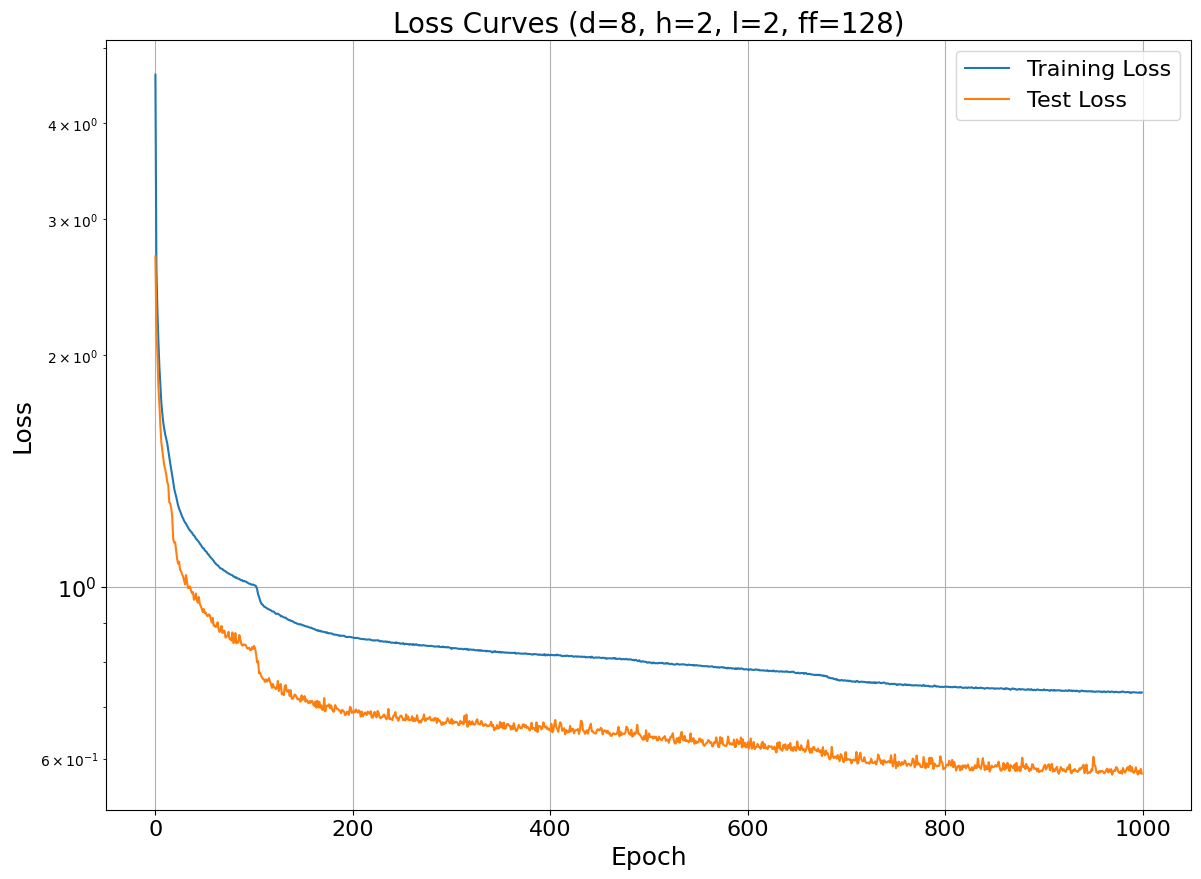

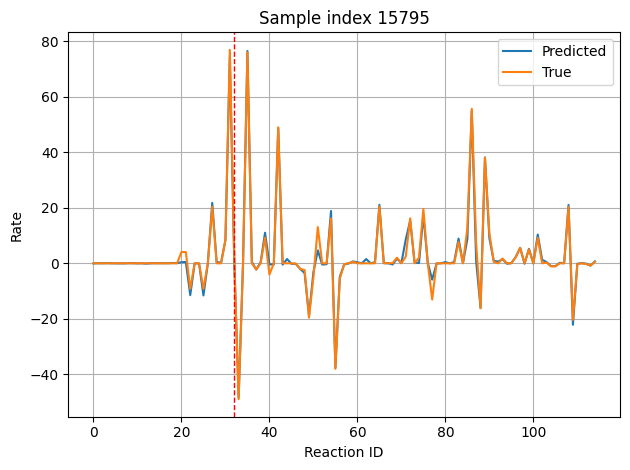

y_pred_outputs.shape: (39227, 95) min/max: -68.00027 109.187904
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.17096555 to 2.8759327


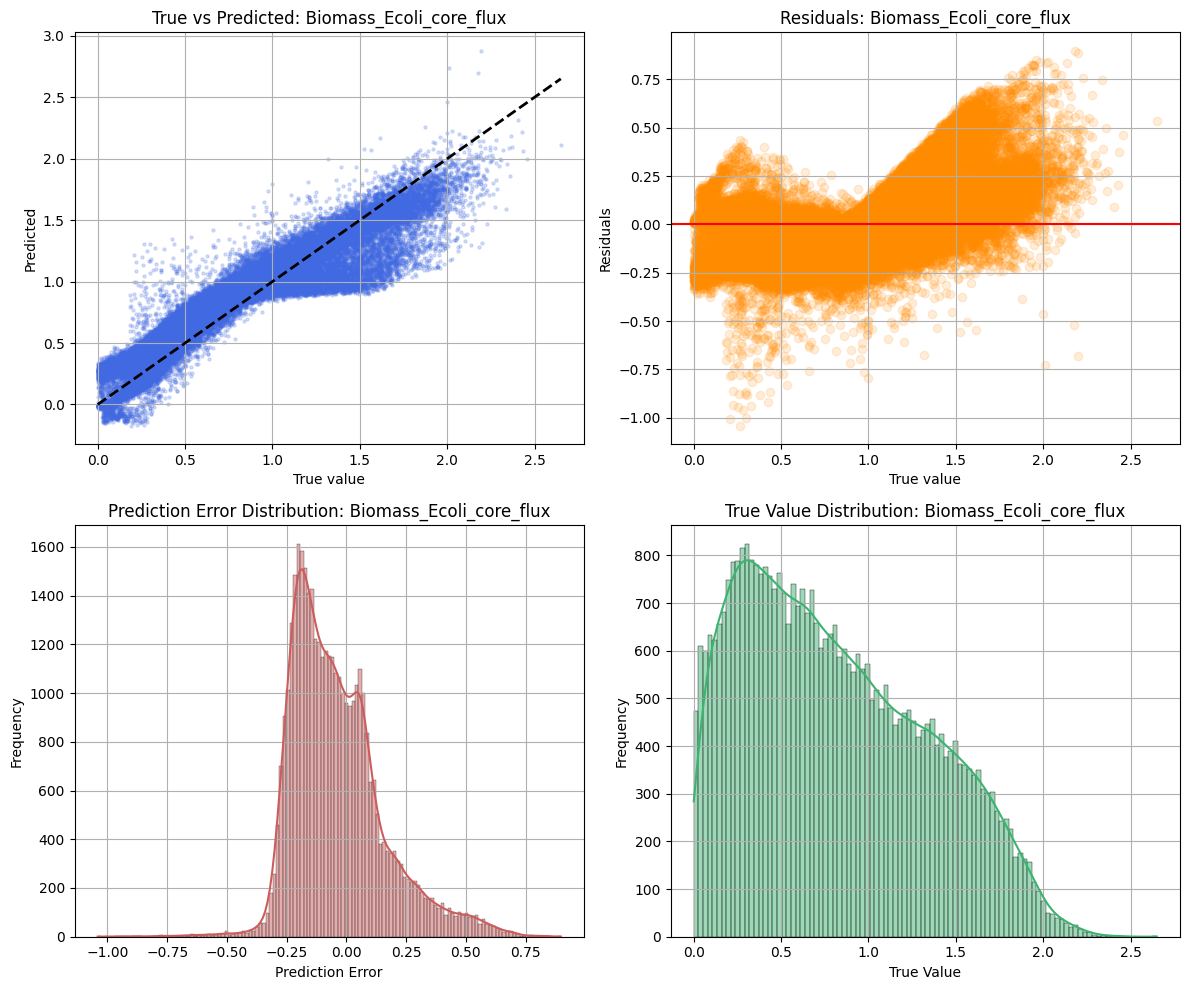

y_pred_outputs.shape: (39227, 95) min/max: -68.00027 109.187904
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -6.239247 to 21.839115


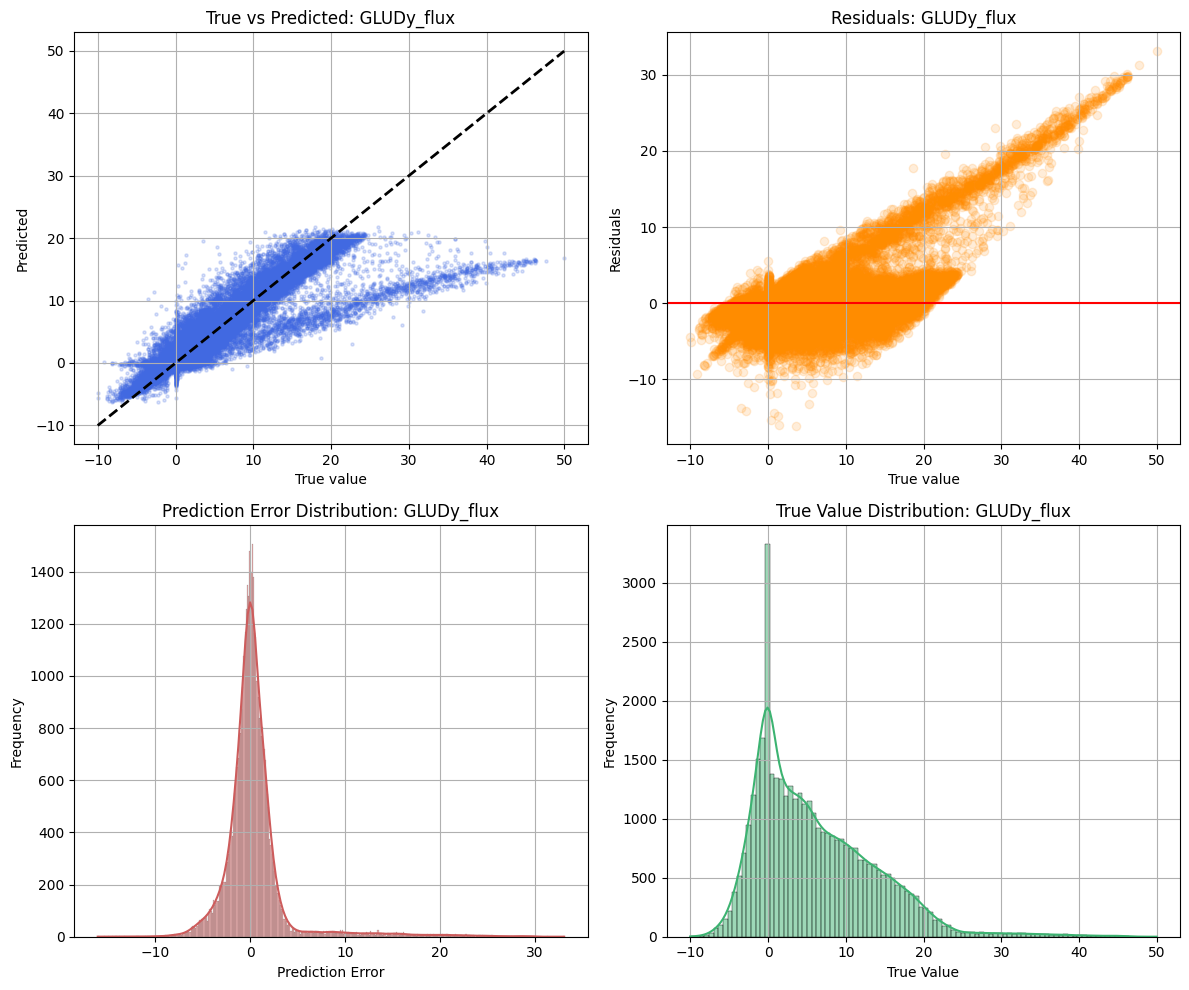

Number of parameters:
6446


In [22]:
train_losses, test_losses, model_822 = train_model(d_model=8, n_heads=2, n_layers=2, d_ff=128, num_epochs=epochs, dropout=dropout)

plot_loss_curves(train_losses, test_losses, d_model=8, n_heads=2, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_822)

for flux_name in diagnostics_to_plot:
    plot_flux(model_822, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_822.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.595534 | Test Loss: 0.463538
Epoch 200/1000 | Train Loss: 0.532921 | Test Loss: 0.421284
Epoch 300/1000 | Train Loss: 0.514780 | Test Loss: 0.406152
Epoch 400/1000 | Train Loss: 0.498041 | Test Loss: 0.391317
Epoch 500/1000 | Train Loss: 0.485027 | Test Loss: 0.373693
Epoch 600/1000 | Train Loss: 0.477137 | Test Loss: 0.373863
Epoch 700/1000 | Train Loss: 0.470015 | Test Loss: 0.373609
Epoch 800/1000 | Train Loss: 0.465896 | Test Loss: 0.372276
Epoch 900/1000 | Train Loss: 0.462075 | Test Loss: 0.362282
Epoch 1000/1000 | Train Loss: 0.458974 | Test Loss: 0.359116
Training Completed.
Training took 143 min 4.5 sec.


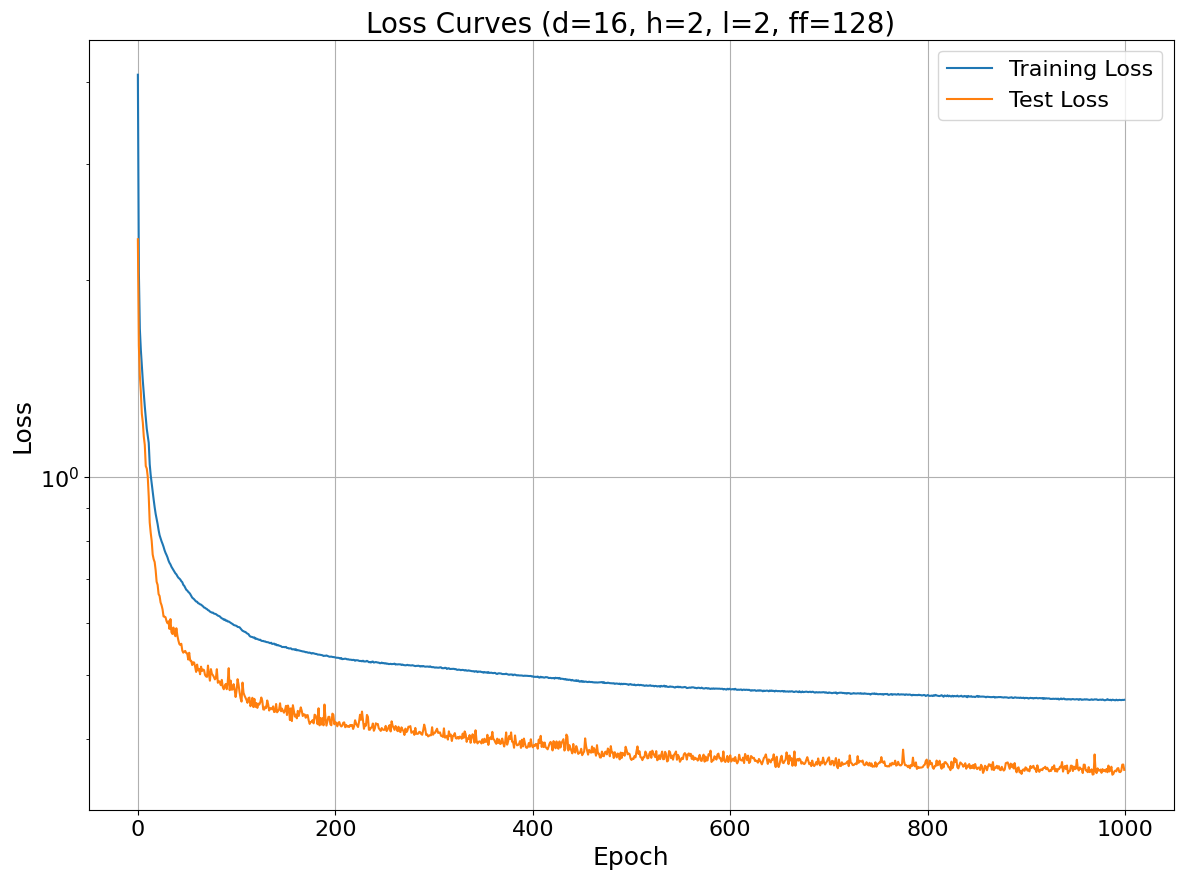

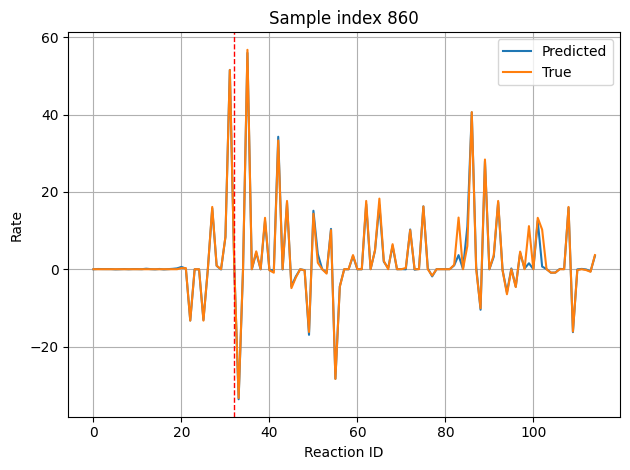

y_pred_outputs.shape: (39227, 95) min/max: -68.85933 104.60971
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.067298174 to 2.6954117


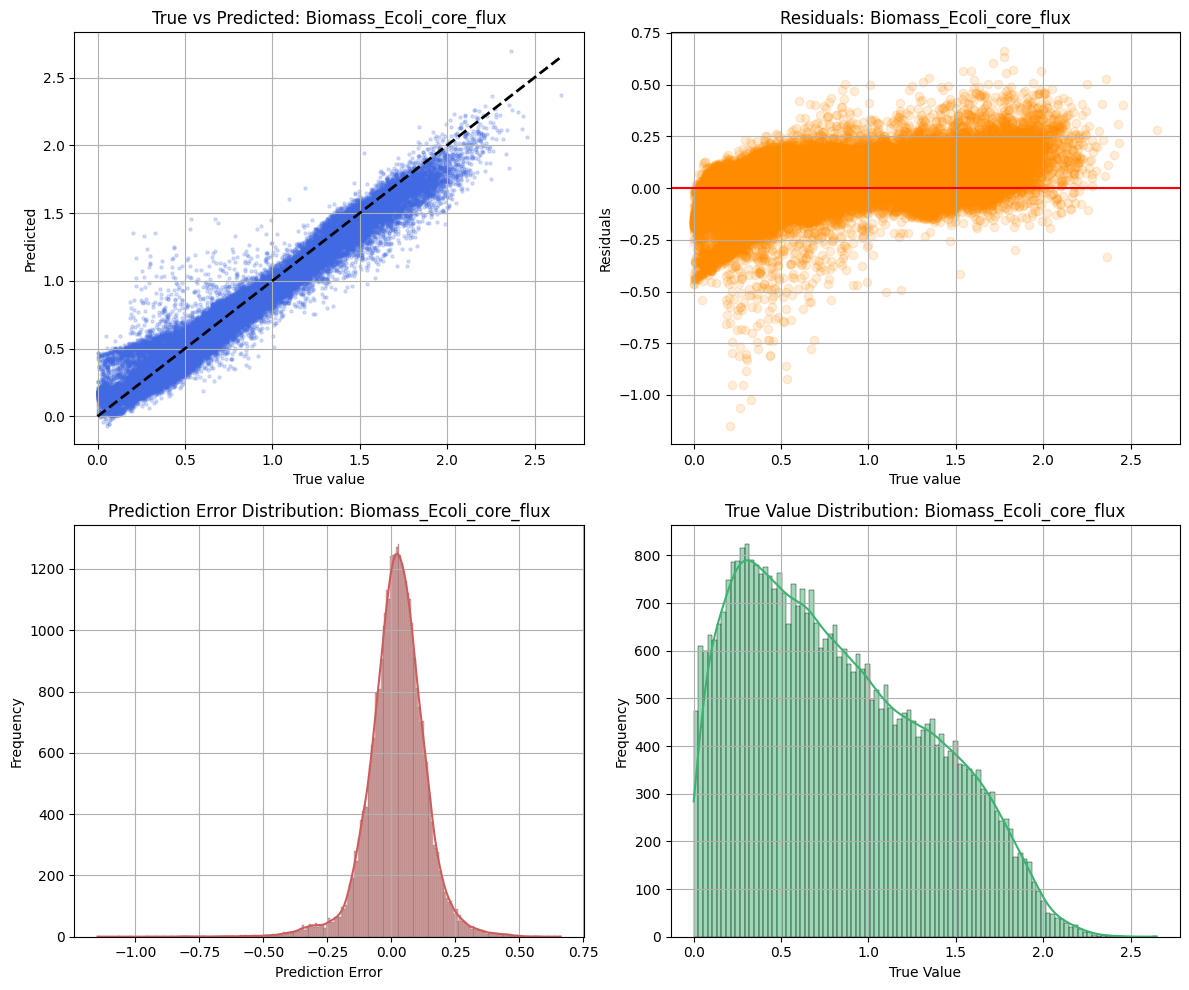

y_pred_outputs.shape: (39227, 95) min/max: -68.85933 104.60971
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -7.1065745 to 24.688538


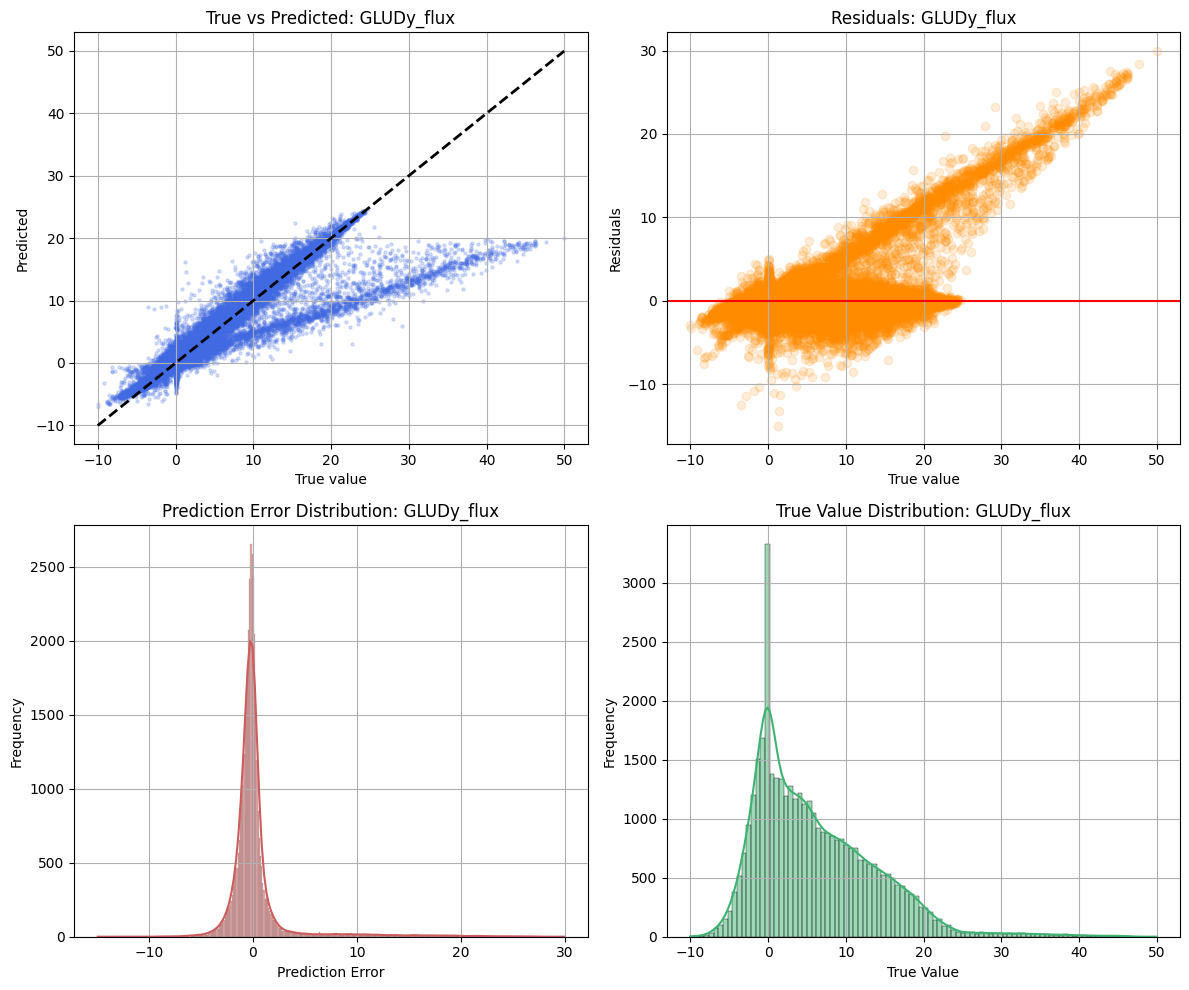

Number of parameters:
13142


In [23]:
train_losses_1622, test_losses_1622, model_1622 = train_model(d_model=16, n_heads=2, n_layers=2, d_ff=128, num_epochs=epochs, dropout=dropout)

plot_loss_curves(train_losses_1622, test_losses_1622, d_model=16, n_heads=2, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_1622)

for flux_name in diagnostics_to_plot:
    plot_flux(model_1622, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_1622.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.568817 | Test Loss: 0.437283
Epoch 200/1000 | Train Loss: 0.507504 | Test Loss: 0.392748
Epoch 300/1000 | Train Loss: 0.472188 | Test Loss: 0.358915
Epoch 400/1000 | Train Loss: 0.448432 | Test Loss: 0.336248
Epoch 500/1000 | Train Loss: 0.435524 | Test Loss: 0.329463
Epoch 600/1000 | Train Loss: 0.428689 | Test Loss: 0.325120
Epoch 700/1000 | Train Loss: 0.422474 | Test Loss: 0.319540
Epoch 800/1000 | Train Loss: 0.417726 | Test Loss: 0.310058
Epoch 900/1000 | Train Loss: 0.413978 | Test Loss: 0.324097
Epoch 1000/1000 | Train Loss: 0.410782 | Test Loss: 0.316787
Training Completed.
Training took 181 min 29.1 sec.


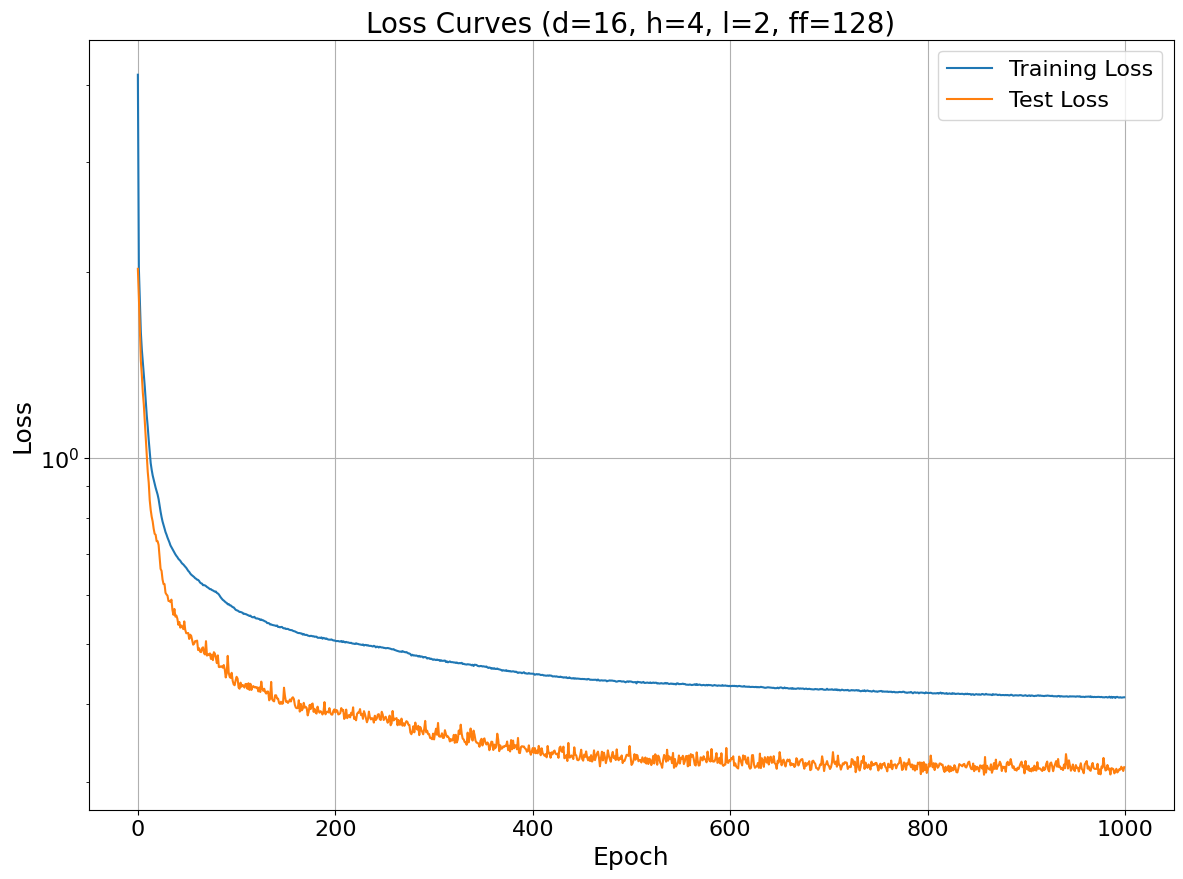

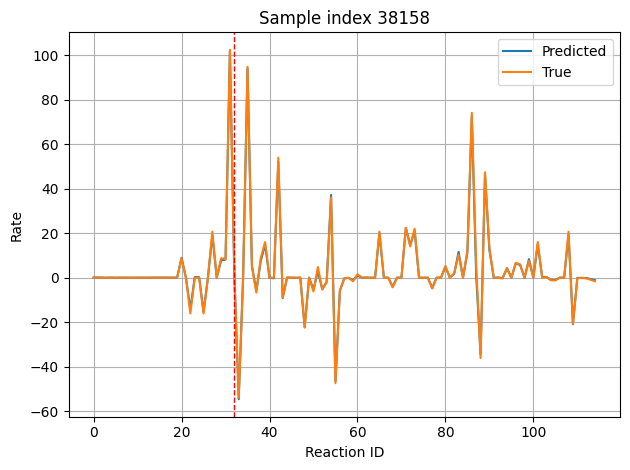

y_pred_outputs.shape: (39227, 95) min/max: -73.084114 107.34819
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.117636174 to 2.2347343


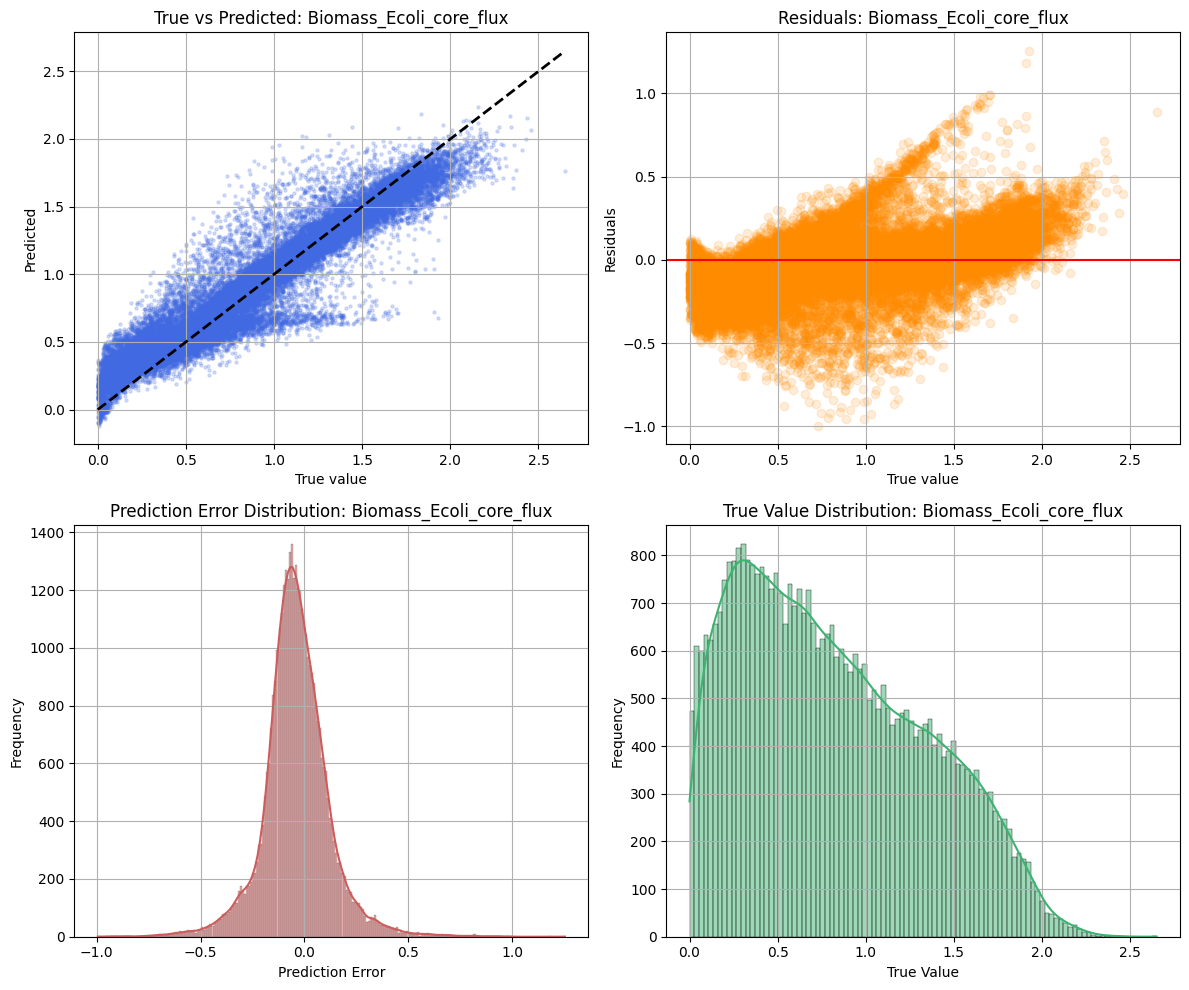

y_pred_outputs.shape: (39227, 95) min/max: -73.084114 107.34819
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -7.1066103 to 24.84668


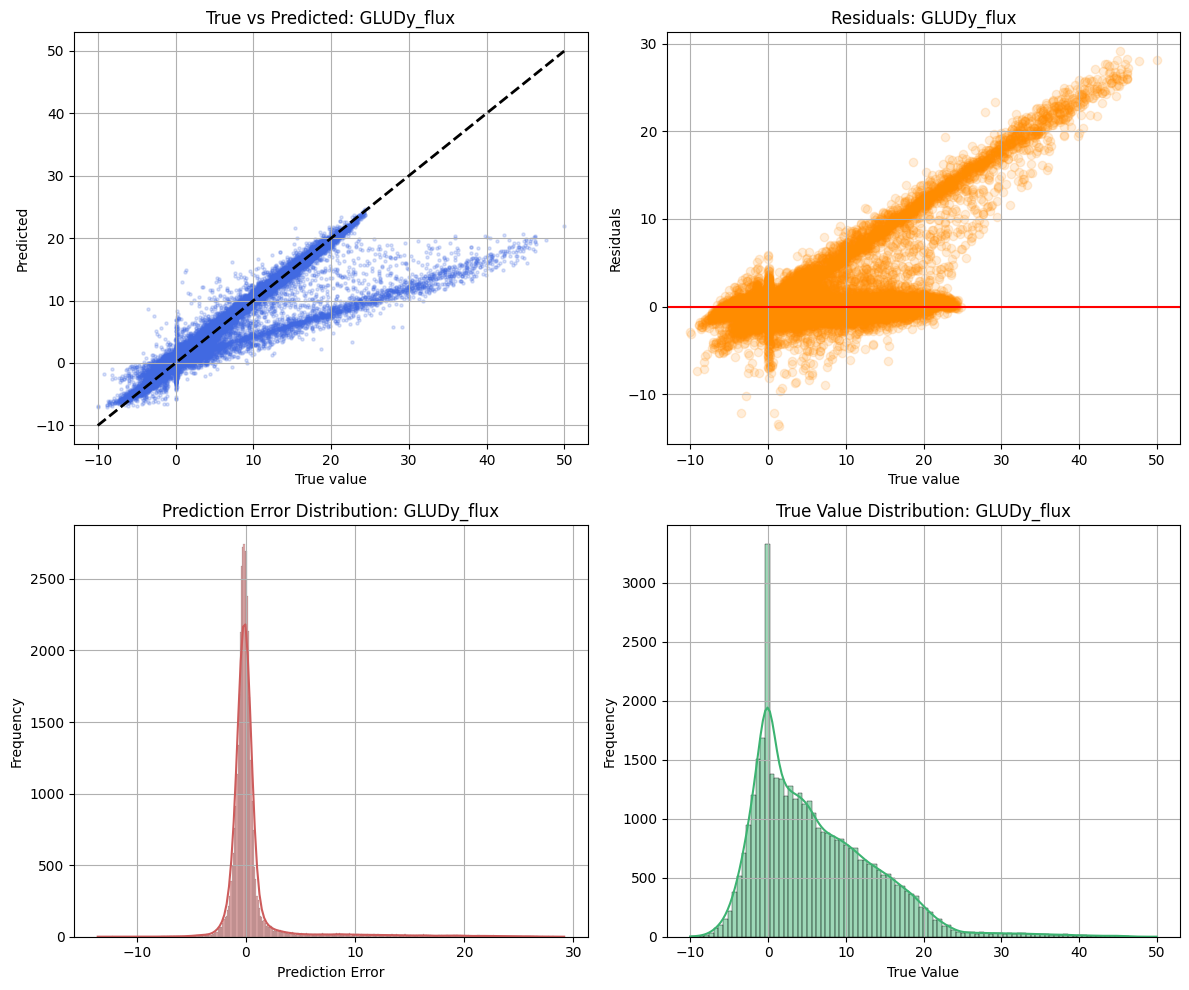

Number of parameters:
13142


In [24]:
train_losses_1642, test_losses_1642, model_1642 = train_model(d_model=16, n_heads=4, n_layers=2, d_ff=128, num_epochs=epochs, dropout=dropout)

plot_loss_curves(train_losses_1642, test_losses_1642, d_model=16, n_heads=4, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_1642)

for flux_name in diagnostics_to_plot:
    plot_flux(model_1642, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_1642.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.405587 | Test Loss: 0.307872
Epoch 200/1000 | Train Loss: 0.366352 | Test Loss: 0.288277
Epoch 300/1000 | Train Loss: 0.349790 | Test Loss: 0.273232
Epoch 400/1000 | Train Loss: 0.341230 | Test Loss: 0.265377
Epoch 500/1000 | Train Loss: 0.334262 | Test Loss: 0.269358
Epoch 600/1000 | Train Loss: 0.329164 | Test Loss: 0.260217
Epoch 700/1000 | Train Loss: 0.324116 | Test Loss: 0.255138
Epoch 800/1000 | Train Loss: 0.320876 | Test Loss: 0.252548
Epoch 900/1000 | Train Loss: 0.318551 | Test Loss: 0.247859
Epoch 1000/1000 | Train Loss: 0.315545 | Test Loss: 0.246319
Training Completed.
Training took 189 min 29.6 sec.


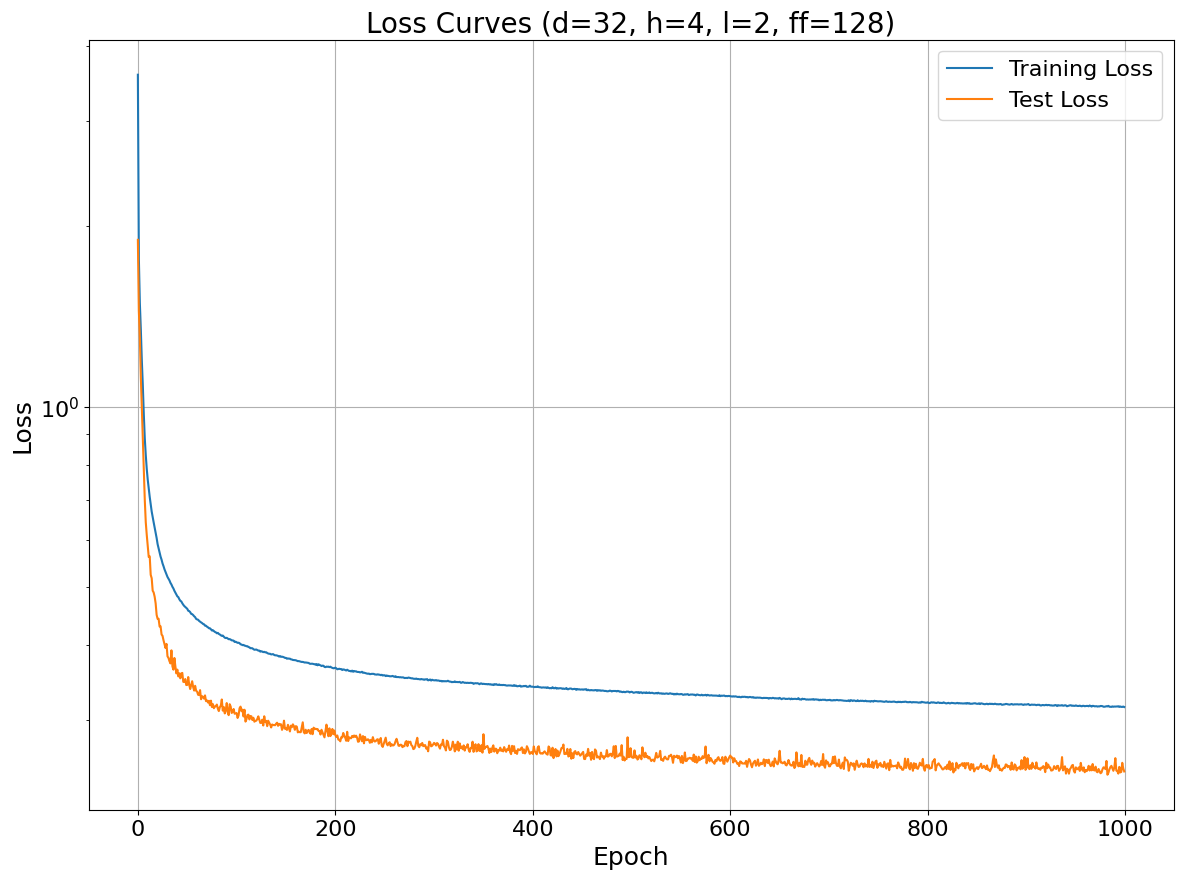

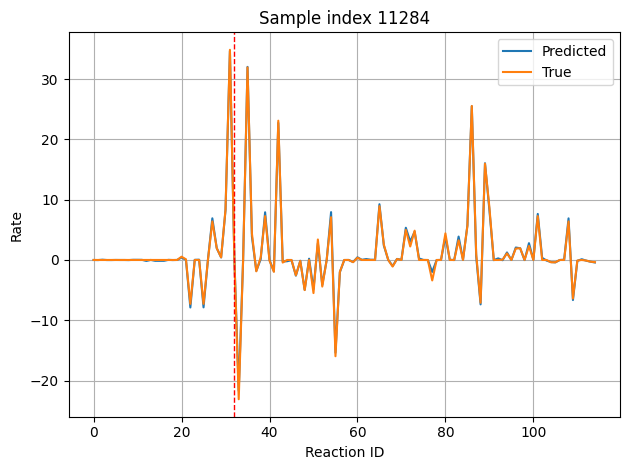

y_pred_outputs.shape: (39227, 95) min/max: -76.96795 107.71688
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.07287359 to 2.2875617


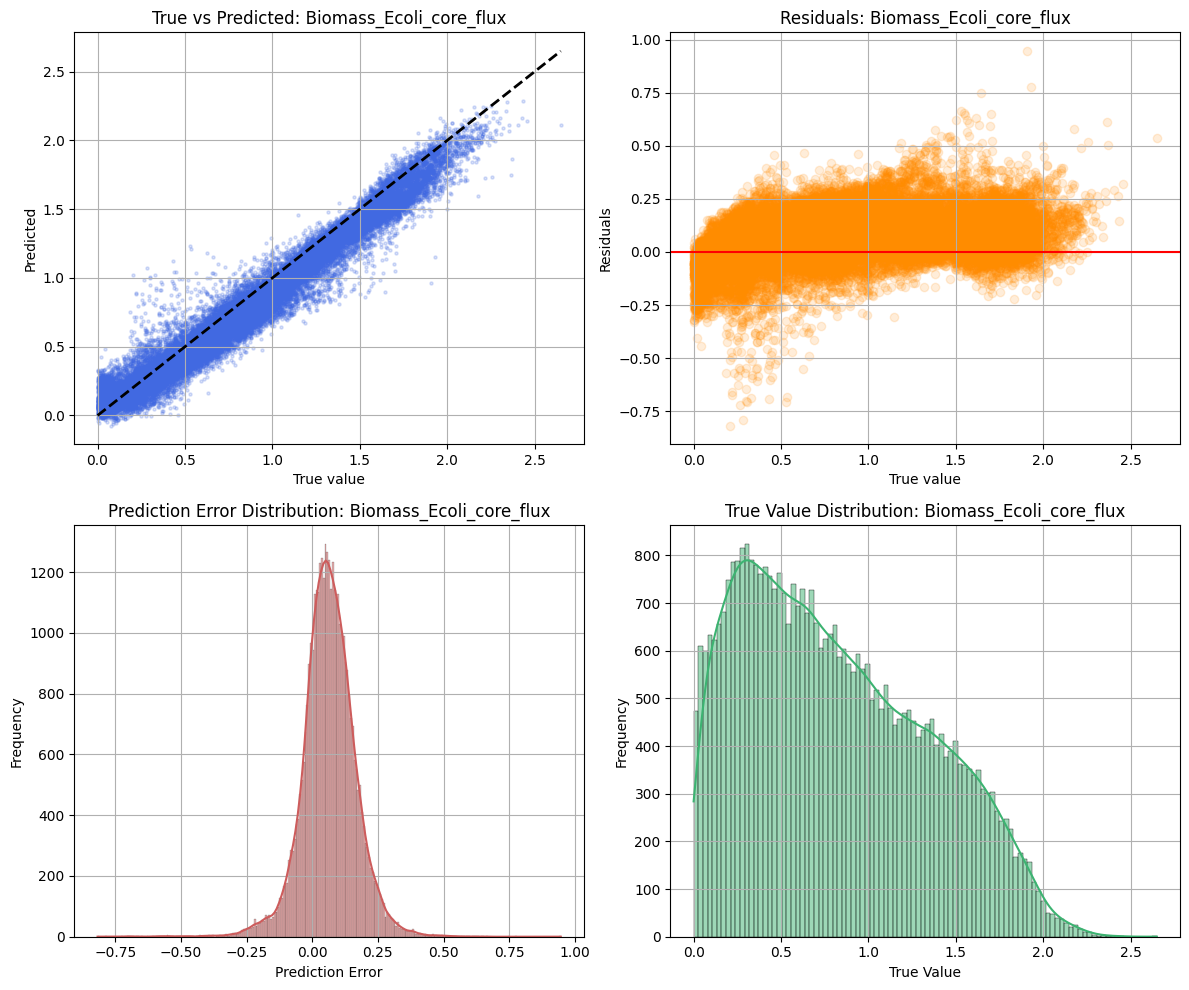

y_pred_outputs.shape: (39227, 95) min/max: -76.96795 107.71688
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -8.736073 to 23.619596


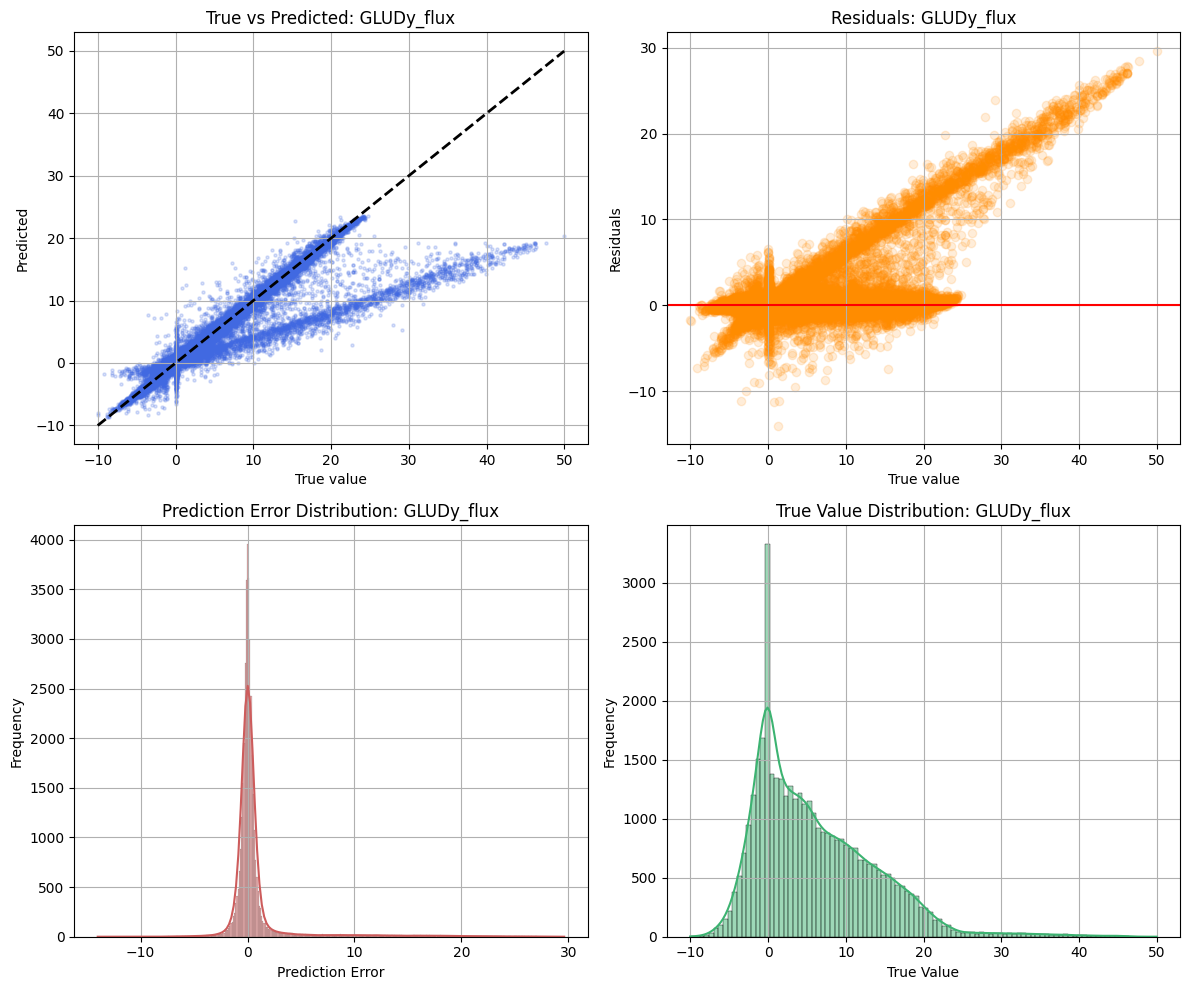

Number of parameters:
29606


In [25]:
train_losses_3242, test_losses_3242, model_3242 = train_model(d_model=32, n_heads=4, n_layers=2, d_ff=128, num_epochs=epochs, dropout=dropout)

plot_loss_curves(train_losses_3242, test_losses_3242, d_model=32, n_heads=4, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_3242)

for flux_name in diagnostics_to_plot:
    plot_flux(model_3242, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_3242.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.295412 | Test Loss: 0.224403
Epoch 200/1000 | Train Loss: 0.259019 | Test Loss: 0.199799
Epoch 300/1000 | Train Loss: 0.244237 | Test Loss: 0.194945
Epoch 400/1000 | Train Loss: 0.234883 | Test Loss: 0.194423
Epoch 500/1000 | Train Loss: 0.230208 | Test Loss: 0.184925
Epoch 600/1000 | Train Loss: 0.226087 | Test Loss: 0.182933
Epoch 700/1000 | Train Loss: 0.223070 | Test Loss: 0.182615
Epoch 800/1000 | Train Loss: 0.219936 | Test Loss: 0.180308
Epoch 900/1000 | Train Loss: 0.218382 | Test Loss: 0.180595
Epoch 1000/1000 | Train Loss: 0.216381 | Test Loss: 0.177673
Training Completed.
Training took 263 min 30.6 sec.


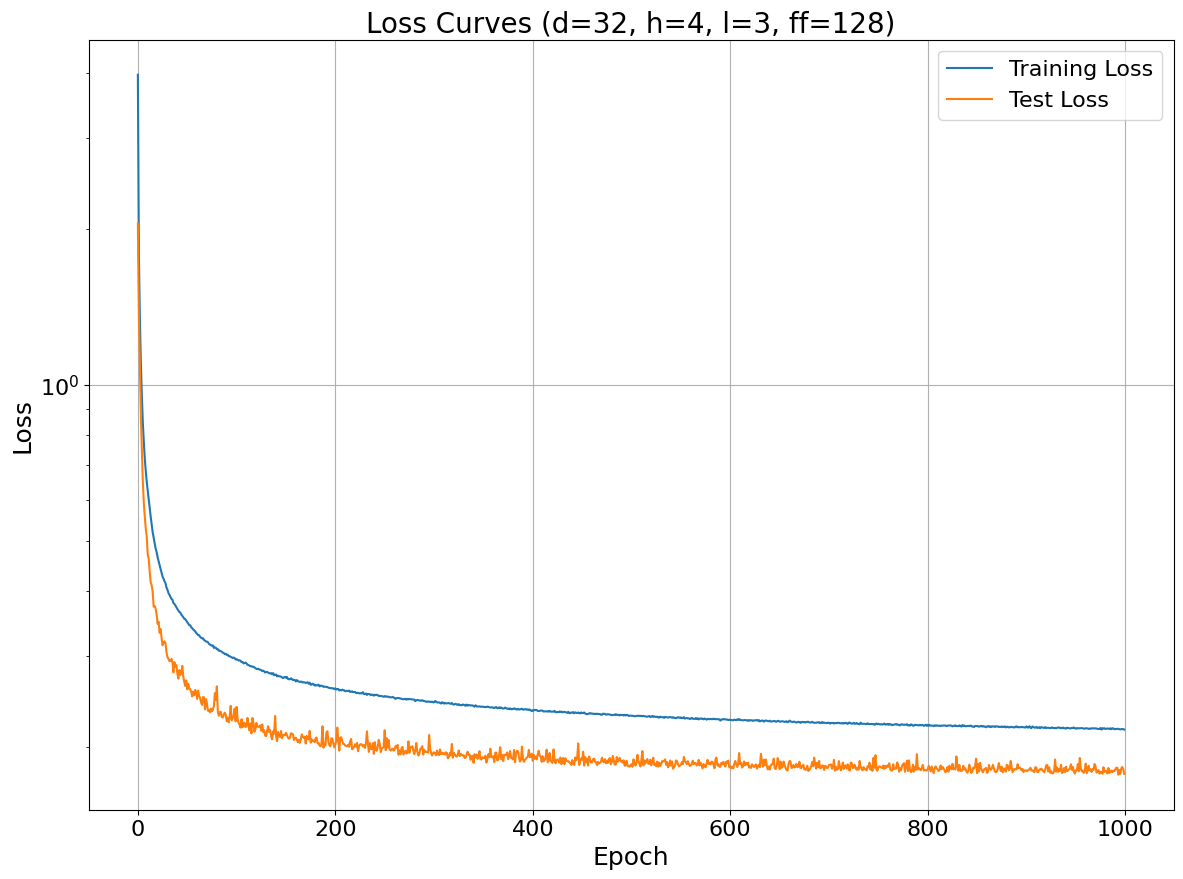

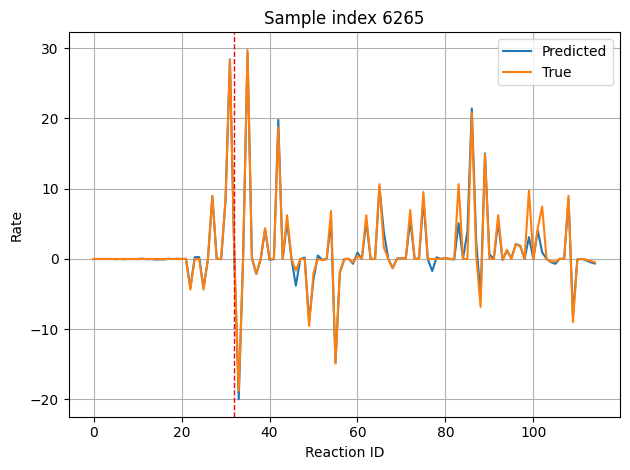

y_pred_outputs.shape: (39227, 95) min/max: -79.11456 109.074554
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.1460759 to 2.559645


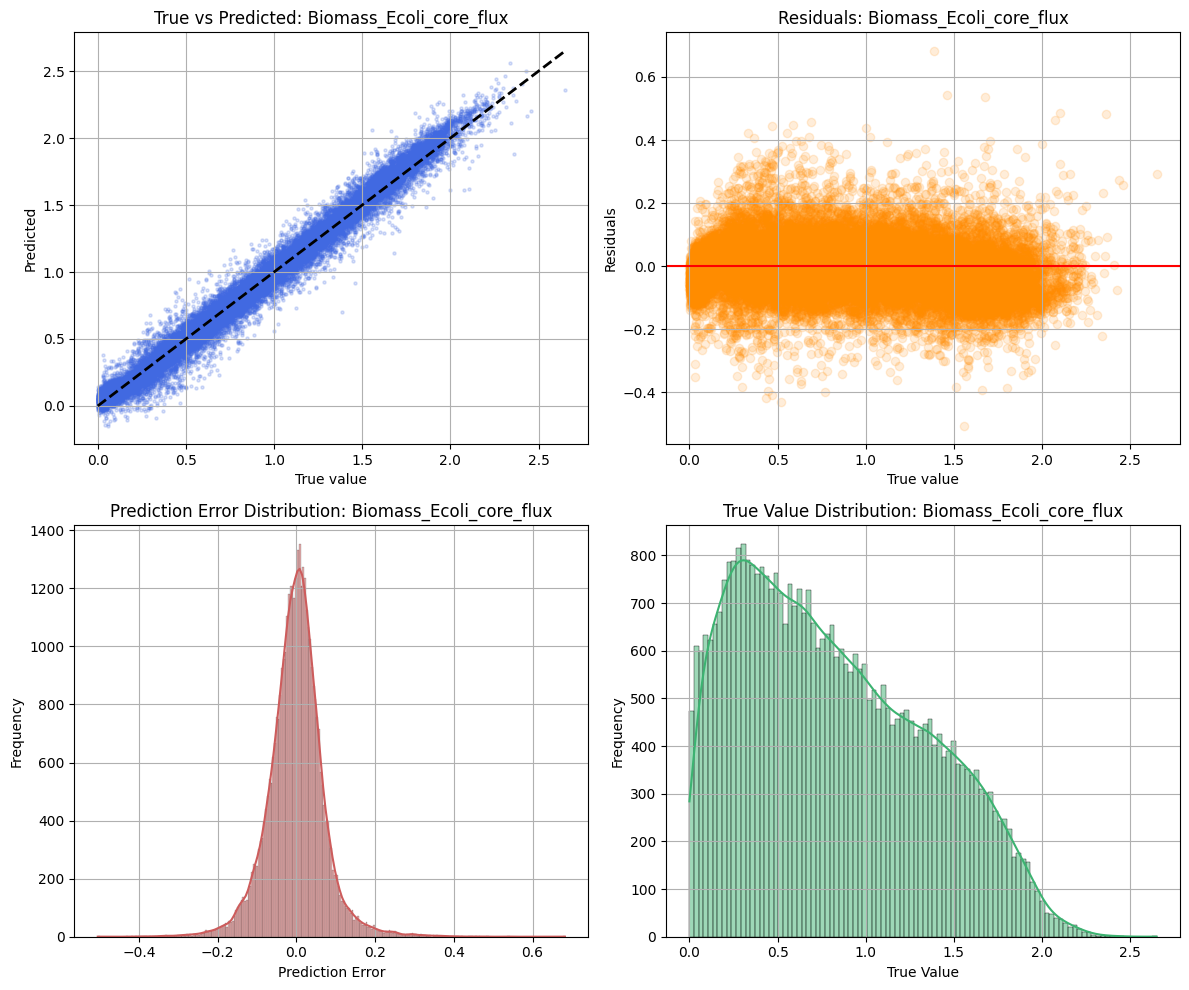

y_pred_outputs.shape: (39227, 95) min/max: -79.11456 109.074554
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -11.1072 to 24.878551


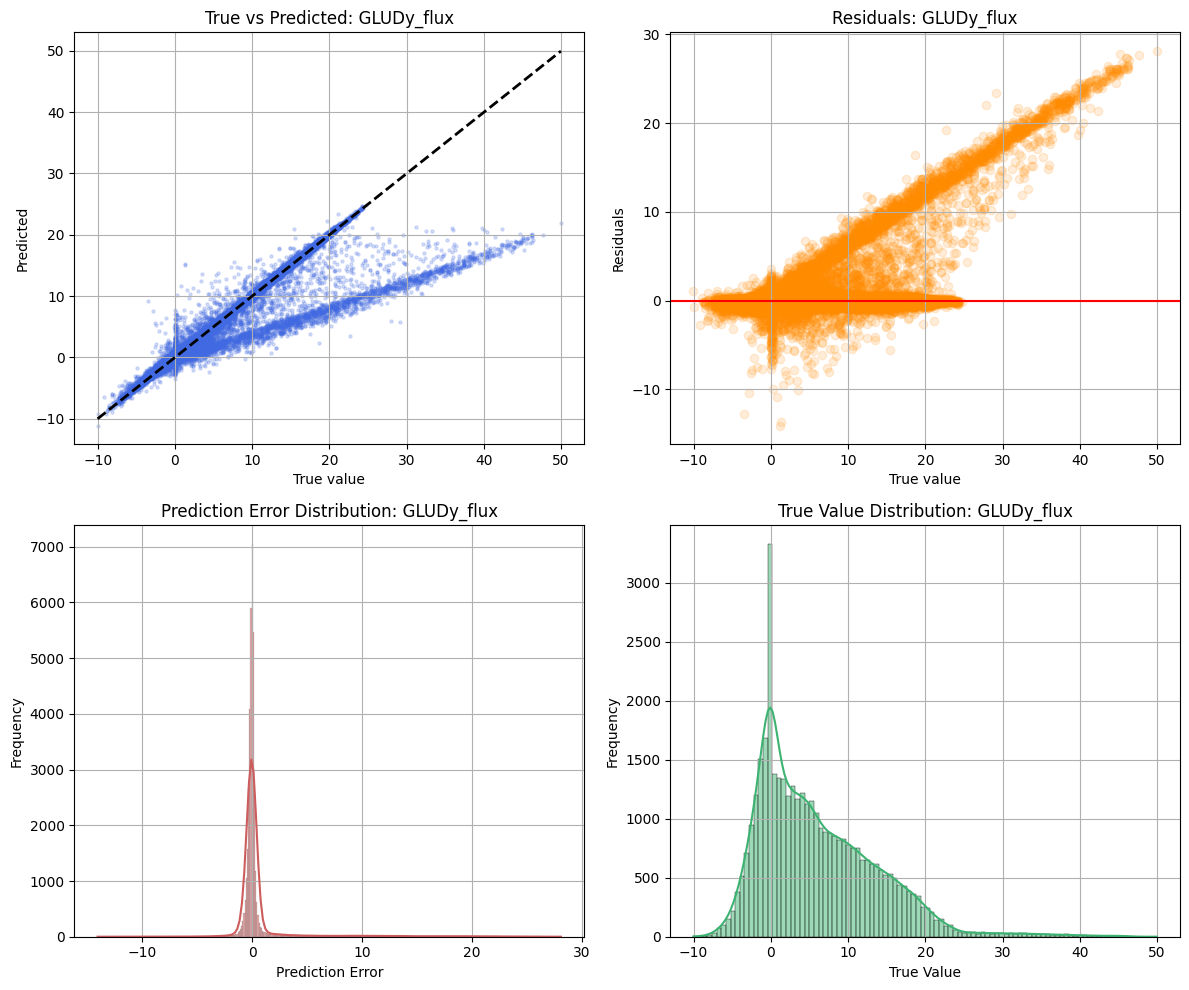

Number of parameters:
42569


In [26]:
train_losses_3243, test_losses_3243, model_3243 = train_model(d_model=32, n_heads=4, n_layers=3, d_ff=128, num_epochs=epochs, dropout=dropout)

plot_loss_curves(train_losses_3243, test_losses_3243, d_model=32, n_heads=4, n_layers=3, d_ff=128)

plot_prediction_sample(X_test, y_test, model_3243)

for flux_name in diagnostics_to_plot:
    plot_flux(model_3243, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_3243.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.269539 | Test Loss: 0.213317
Epoch 200/1000 | Train Loss: 0.234371 | Test Loss: 0.188080
Epoch 300/1000 | Train Loss: 0.221301 | Test Loss: 0.183608
Epoch 400/1000 | Train Loss: 0.213349 | Test Loss: 0.183515
Epoch 500/1000 | Train Loss: 0.208318 | Test Loss: 0.181769
Epoch 600/1000 | Train Loss: 0.204167 | Test Loss: 0.175908
Epoch 700/1000 | Train Loss: 0.201303 | Test Loss: 0.174280
Epoch 800/1000 | Train Loss: 0.199649 | Test Loss: 0.171839
Epoch 900/1000 | Train Loss: 0.197492 | Test Loss: 0.170338
Epoch 1000/1000 | Train Loss: 0.194866 | Test Loss: 0.172565
Training Completed.
Training took 293 min 30.4 sec.


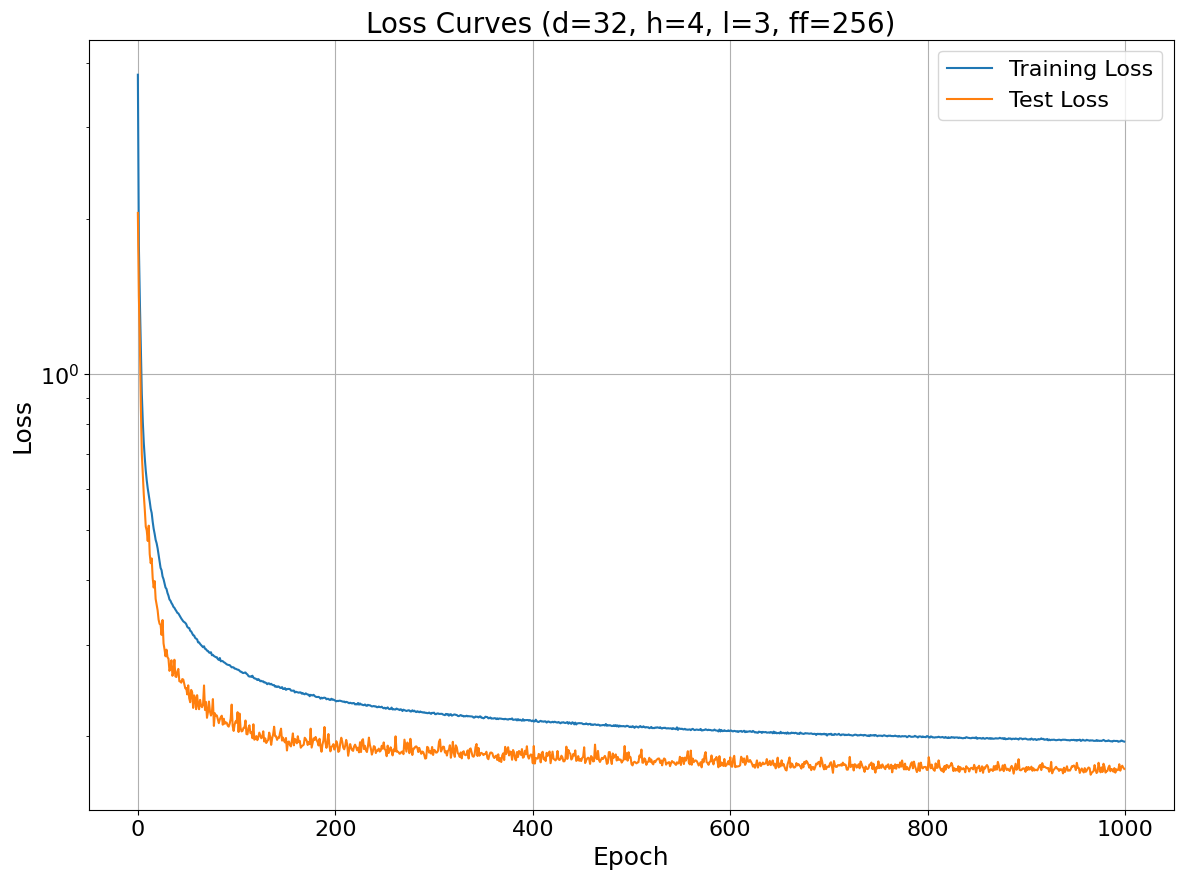

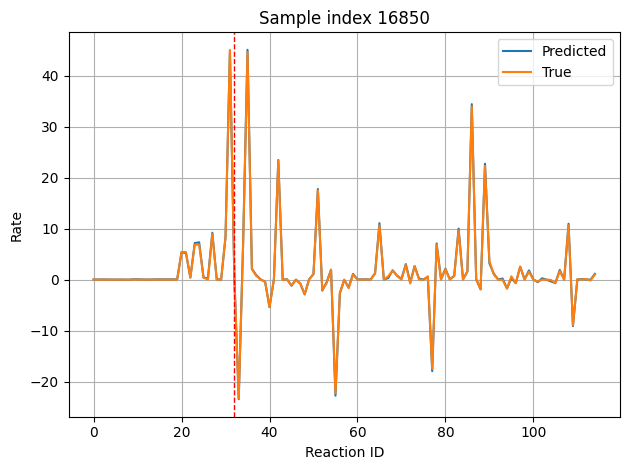

y_pred_outputs.shape: (39227, 95) min/max: -79.74323 107.76668
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.38761848 to 2.8606913


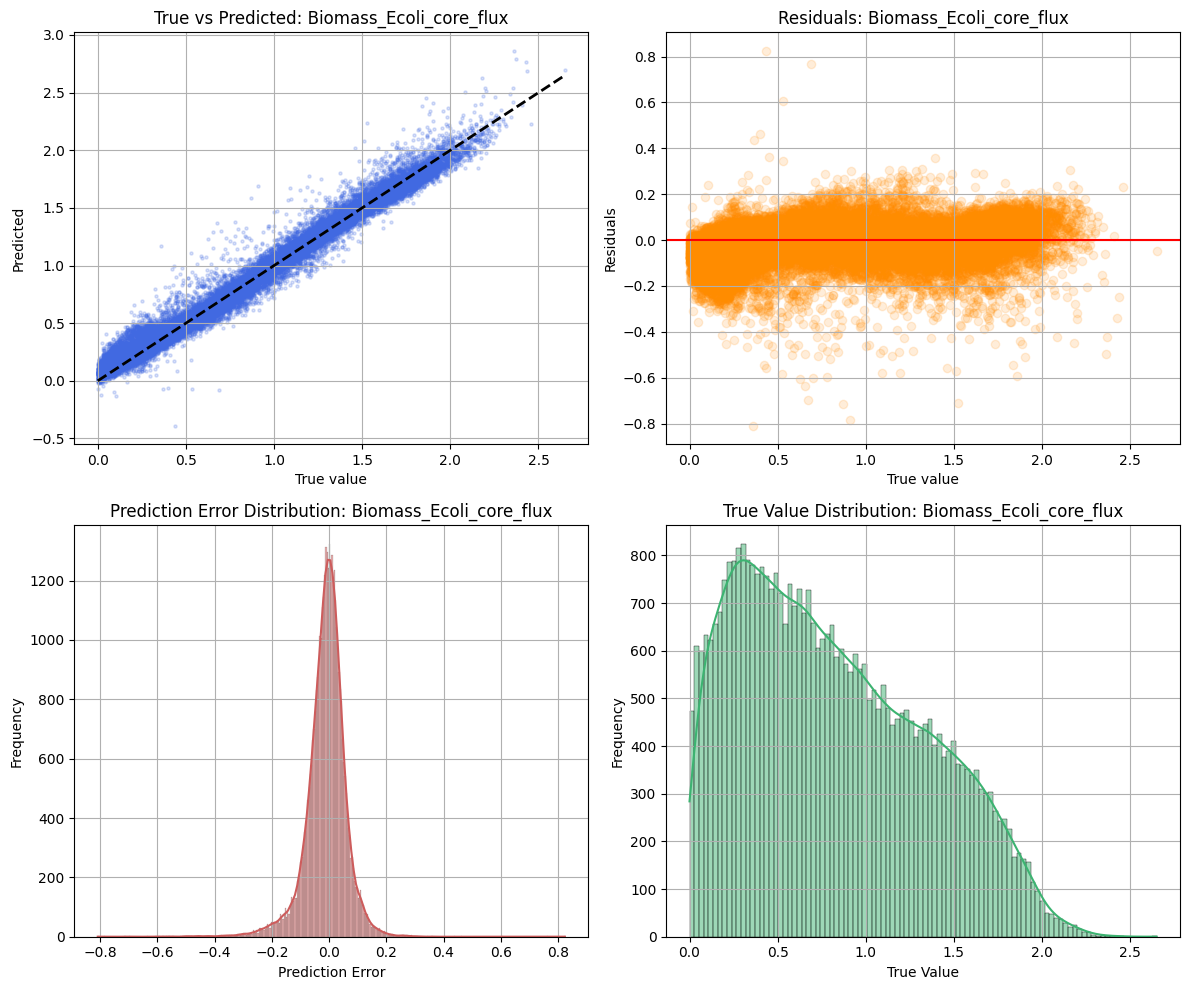

y_pred_outputs.shape: (39227, 95) min/max: -79.74323 107.76668
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -10.211691 to 24.417698


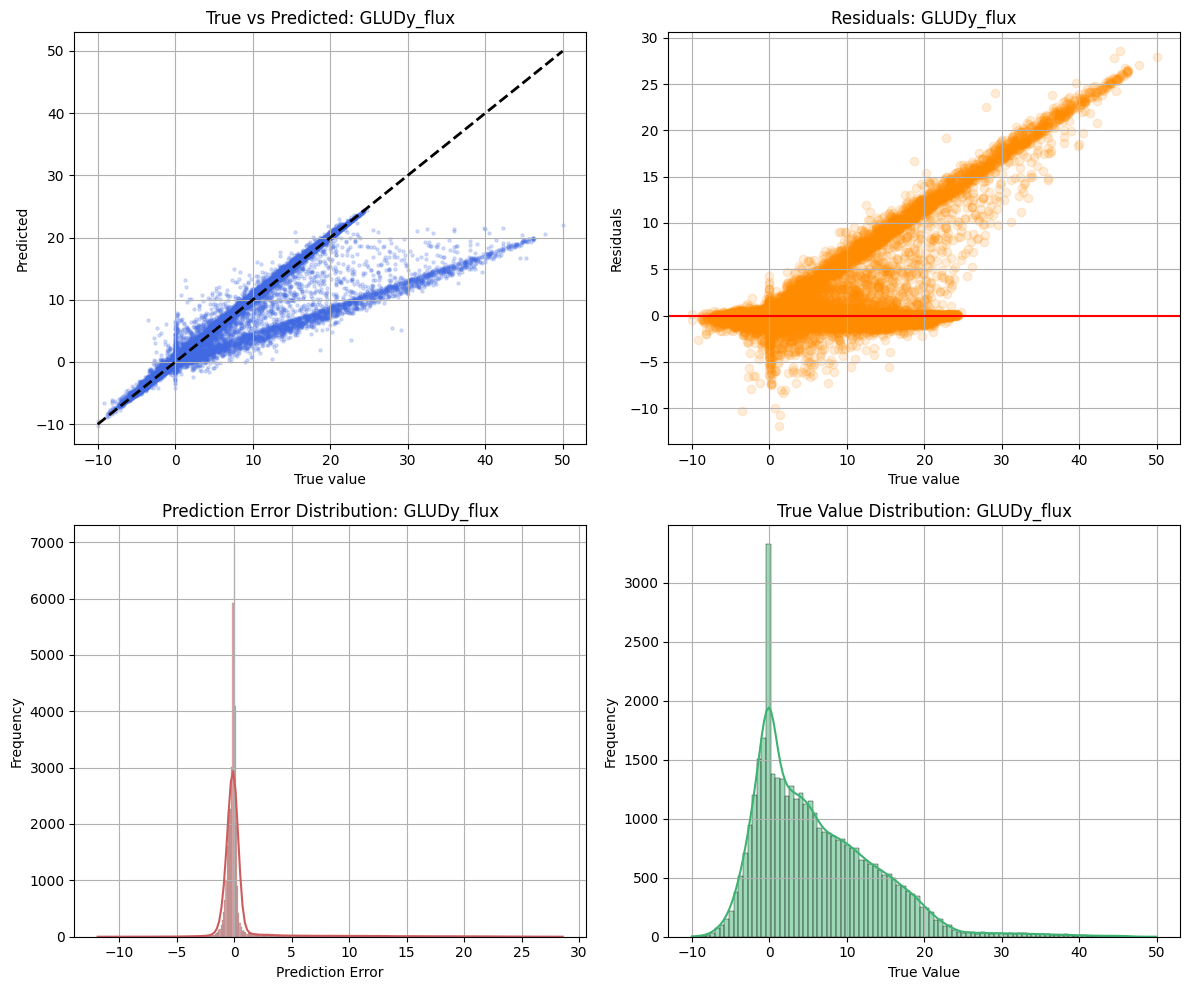

Number of parameters:
68297


In [27]:
train_losses_3243_256, test_losses_3243_256, model_3243_256 = train_model(d_model=32, n_heads=4, n_layers=3, d_ff=256, num_epochs=epochs, dropout=dropout)

plot_loss_curves(train_losses_3243_256, test_losses_3243_256, d_model=32, n_heads=4, n_layers=3, d_ff=256)

plot_prediction_sample(X_test, y_test, model_3243_256)

for flux_name in diagnostics_to_plot:
    plot_flux(model_3243_256, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_3243_256.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.289990 | Test Loss: 0.236221
Epoch 200/1000 | Train Loss: 0.263795 | Test Loss: 0.220855
Epoch 300/1000 | Train Loss: 0.251324 | Test Loss: 0.209203
Epoch 400/1000 | Train Loss: 0.244643 | Test Loss: 0.204105
Epoch 500/1000 | Train Loss: 0.239905 | Test Loss: 0.201186
Epoch 600/1000 | Train Loss: 0.236507 | Test Loss: 0.198955
Epoch 700/1000 | Train Loss: 0.234123 | Test Loss: 0.196124
Epoch 800/1000 | Train Loss: 0.232037 | Test Loss: 0.193997
Epoch 900/1000 | Train Loss: 0.229947 | Test Loss: 0.195473
Epoch 1000/1000 | Train Loss: 0.228643 | Test Loss: 0.191181
Training Completed.
Training took 250 min 19.5 sec.


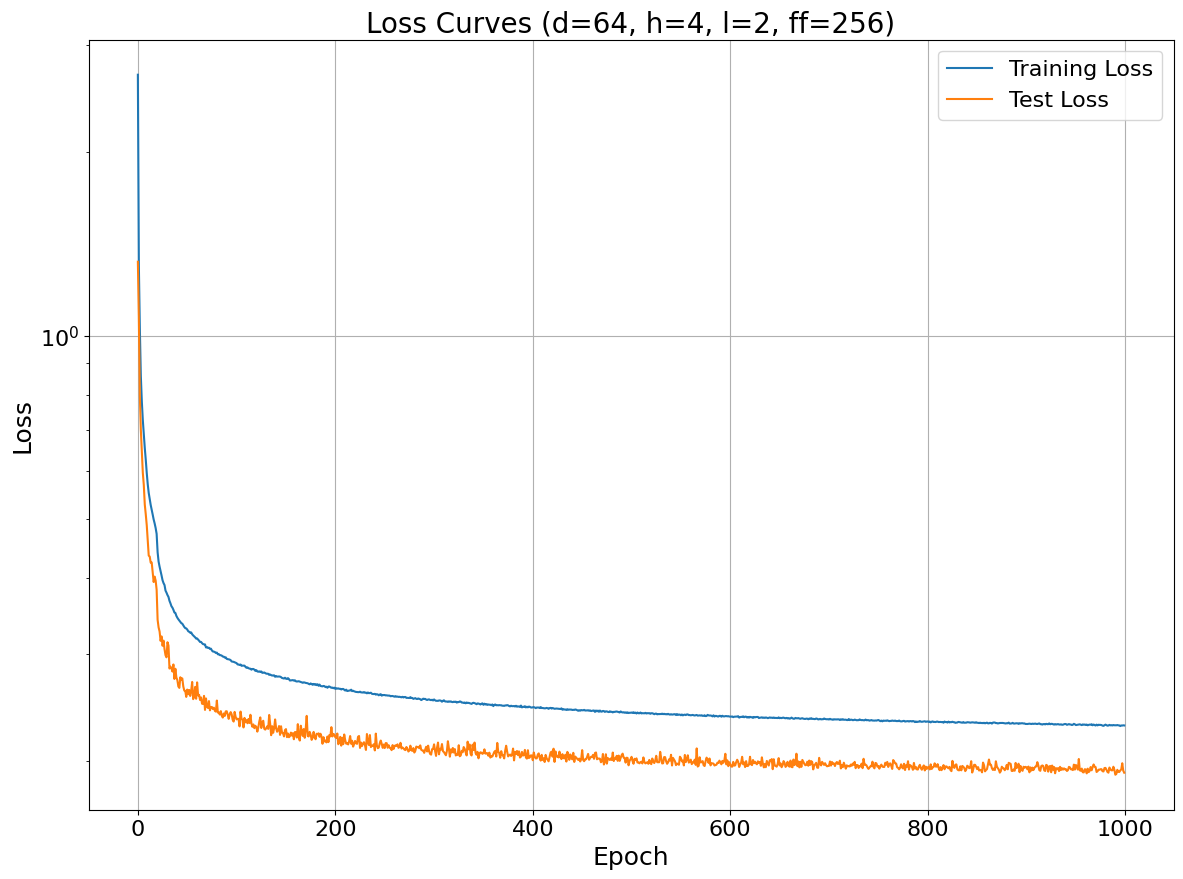

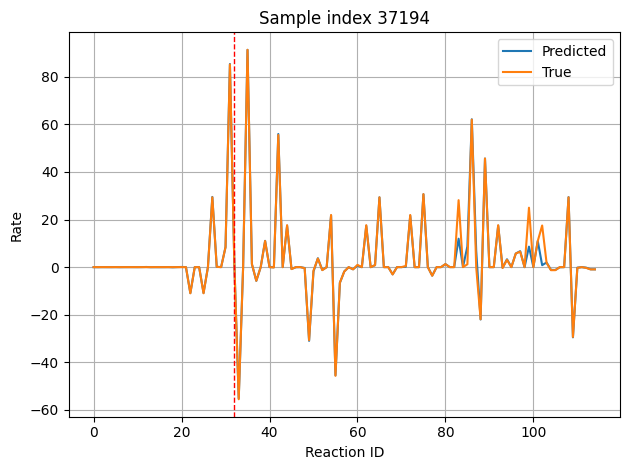

y_pred_outputs.shape: (39227, 95) min/max: -77.60222 108.466484
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.07930815 to 2.5020182


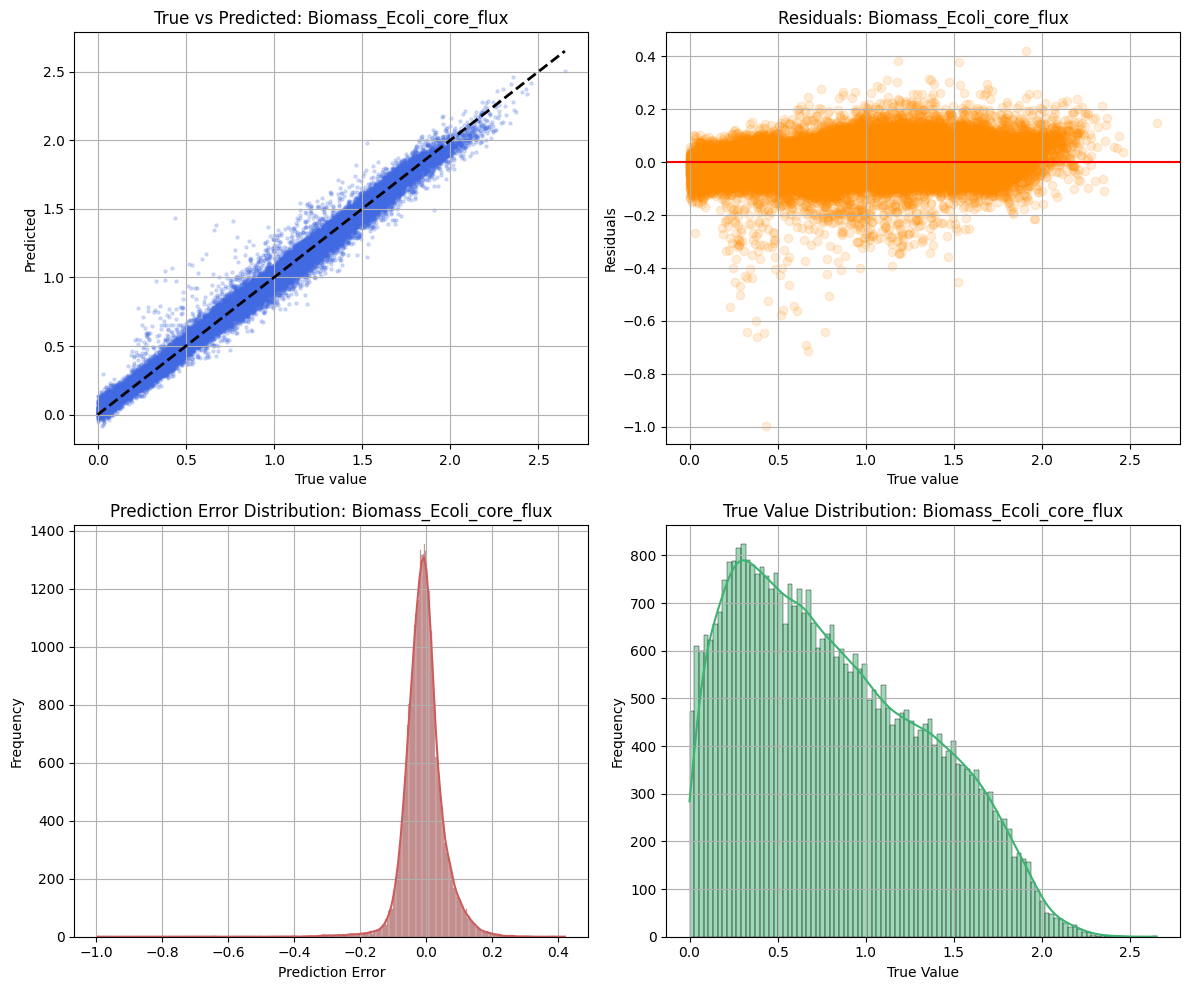

y_pred_outputs.shape: (39227, 95) min/max: -77.60222 108.466484
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -8.542763 to 24.614378


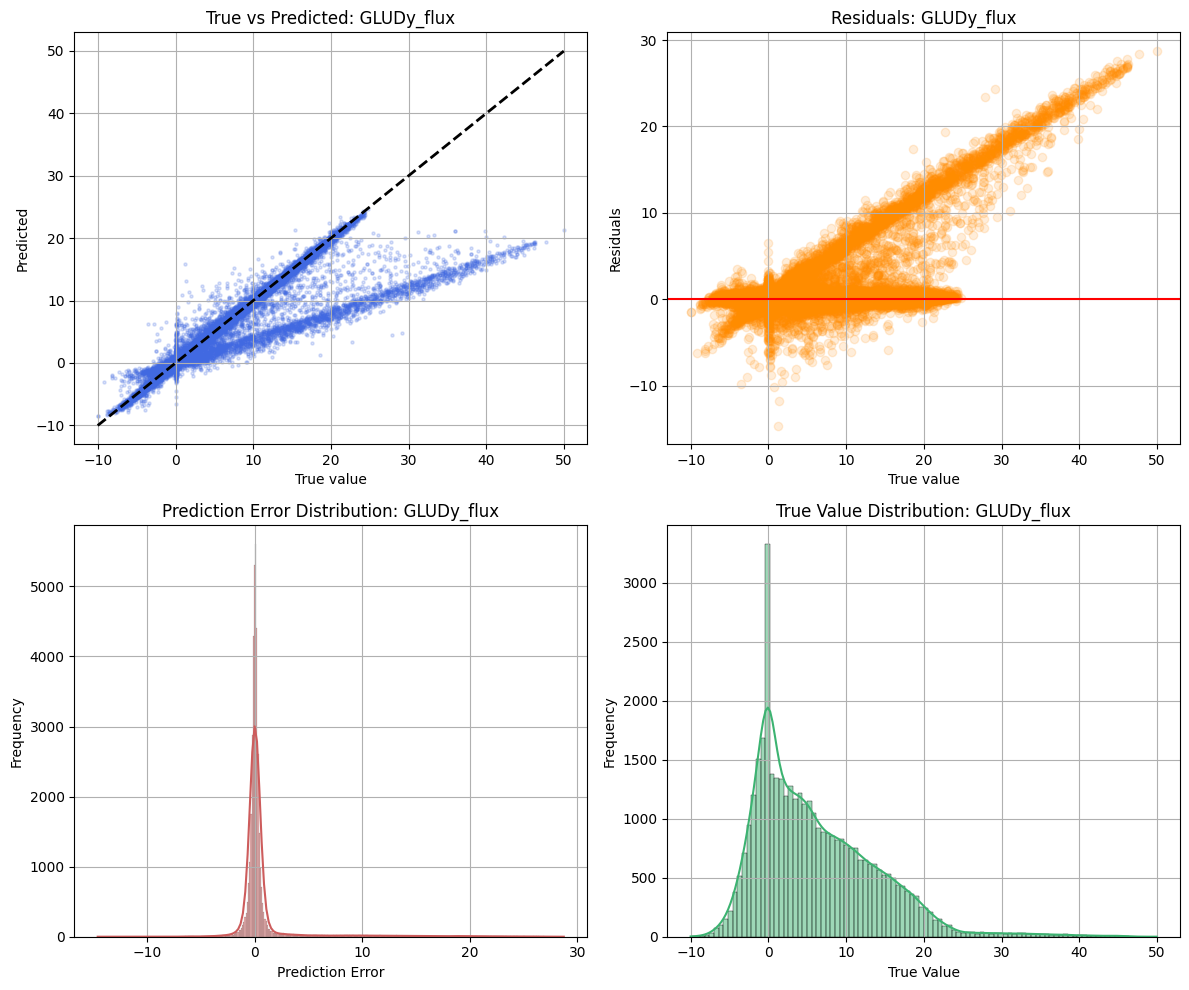

Number of parameters:
108358


In [28]:
train_losses_6442_256, test_losses_6442_256, model_6442_256 = train_model(d_model=64, n_heads=4, n_layers=2, d_ff=256, num_epochs=epochs, dropout=dropout)

plot_loss_curves(train_losses_6442_256, test_losses_6442_256, d_model=64, n_heads=4, n_layers=2, d_ff=256)

plot_prediction_sample(X_test, y_test, model_6442_256)

for flux_name in diagnostics_to_plot:
    plot_flux(model_6442_256, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_6442_256.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.222311 | Test Loss: 0.187718
Epoch 200/1000 | Train Loss: 0.201692 | Test Loss: 0.179662
Epoch 300/1000 | Train Loss: 0.193229 | Test Loss: 0.175567
Epoch 400/1000 | Train Loss: 0.187344 | Test Loss: 0.170392
Epoch 500/1000 | Train Loss: 0.183703 | Test Loss: 0.169603
Epoch 600/1000 | Train Loss: 0.180812 | Test Loss: 0.169238
Epoch 700/1000 | Train Loss: 0.178079 | Test Loss: 0.168886
Epoch 800/1000 | Train Loss: 0.176772 | Test Loss: 0.166724
Epoch 900/1000 | Train Loss: 0.174665 | Test Loss: 0.165409
Epoch 1000/1000 | Train Loss: 0.172891 | Test Loss: 0.164972
Training Completed.
Training took 339 min 45.3 sec.


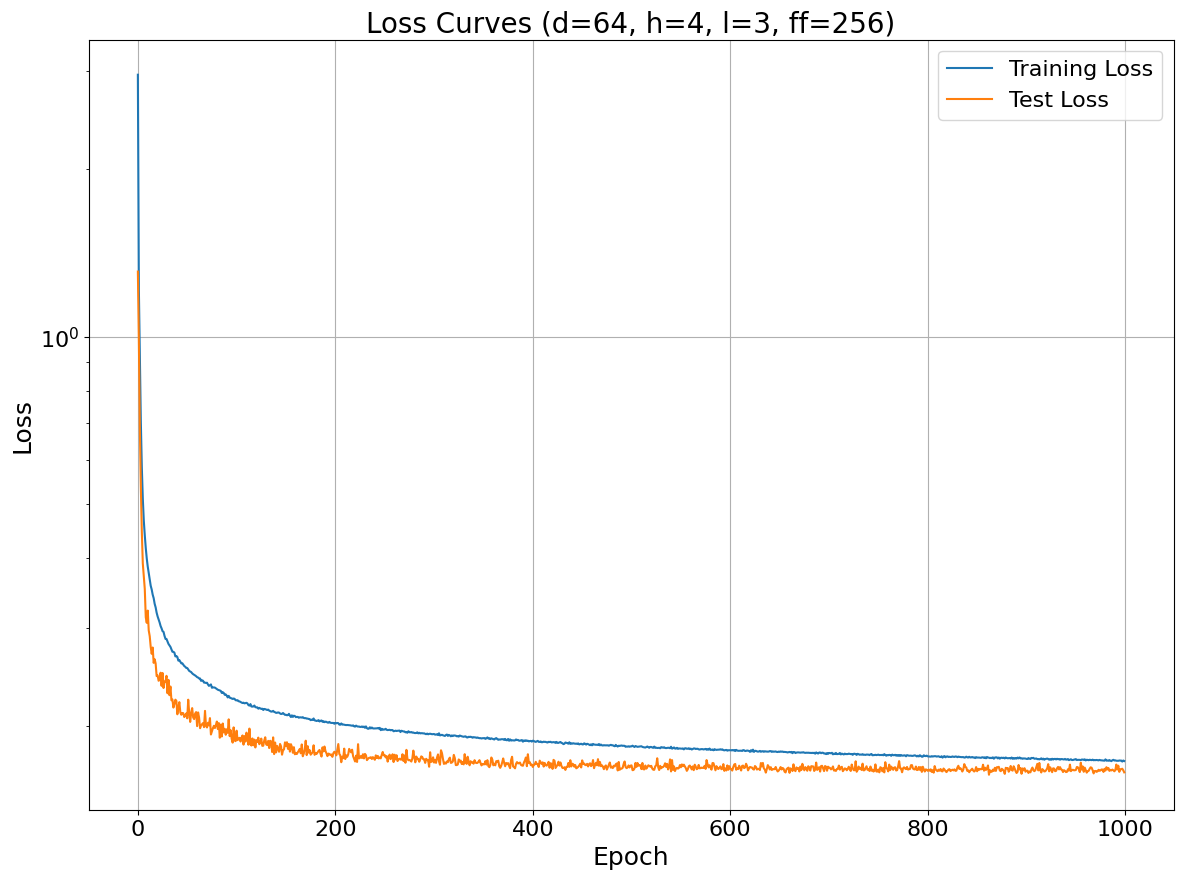

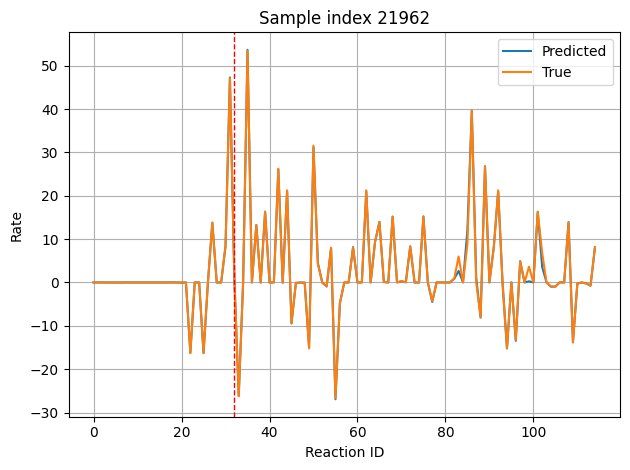

y_pred_outputs.shape: (39227, 95) min/max: -80.29952 109.05916
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.054060936 to 2.4293501


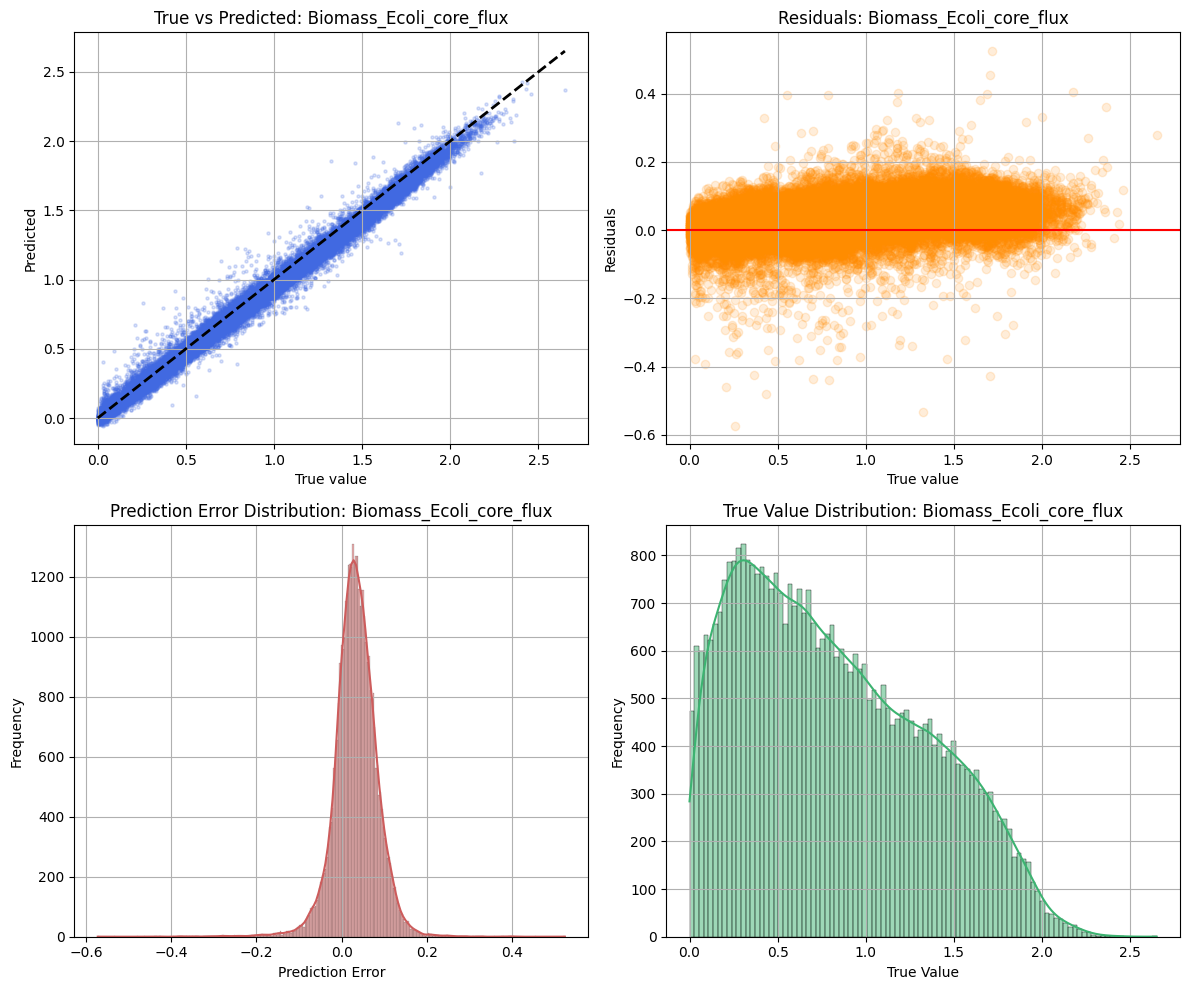

y_pred_outputs.shape: (39227, 95) min/max: -80.29952 109.05916
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -10.268265 to 24.540901


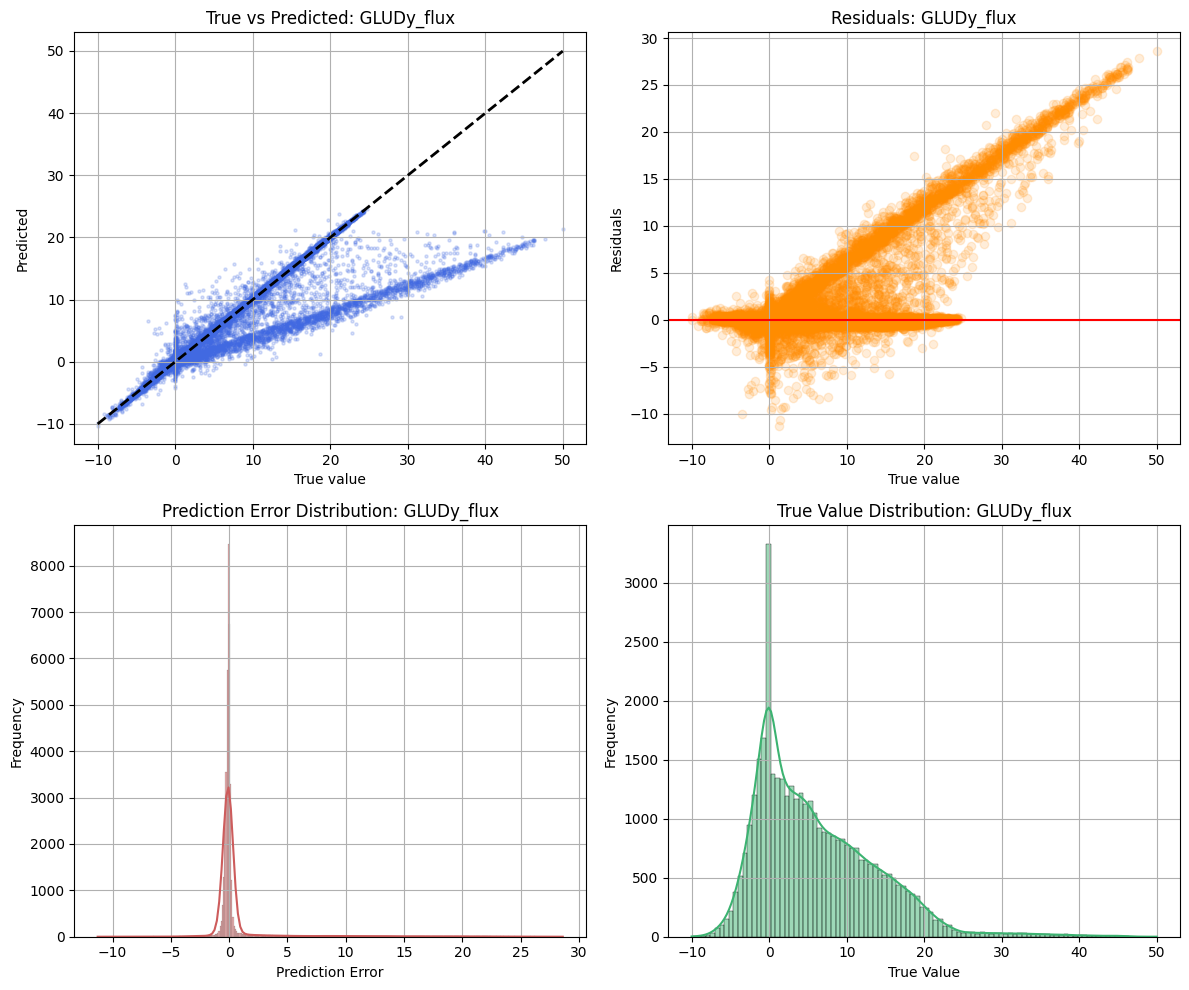

Number of parameters:
158857


In [29]:
train_losses_6443_256, test_losses_6443_256, model_6443_256 = train_model(d_model=64, n_heads=4, n_layers=3, d_ff=256, num_epochs=epochs, dropout=dropout)

plot_loss_curves(train_losses_6443_256, test_losses_6443_256, d_model=64, n_heads=4, n_layers=3, d_ff=256)

plot_prediction_sample(X_test, y_test, model_6443_256)

for flux_name in diagnostics_to_plot:
    plot_flux(model_6443_256, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_6443_256.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.212130 | Test Loss: 0.178040
Epoch 200/1000 | Train Loss: 0.195652 | Test Loss: 0.174015
Epoch 300/1000 | Train Loss: 0.187672 | Test Loss: 0.168823
Epoch 400/1000 | Train Loss: 0.182639 | Test Loss: 0.171901
Epoch 500/1000 | Train Loss: 0.179582 | Test Loss: 0.165391
Epoch 600/1000 | Train Loss: 0.177015 | Test Loss: 0.169029
Epoch 700/1000 | Train Loss: 0.174069 | Test Loss: 0.168848
Epoch 800/1000 | Train Loss: 0.172253 | Test Loss: 0.165646
Epoch 900/1000 | Train Loss: 0.169495 | Test Loss: 0.168126
Epoch 1000/1000 | Train Loss: 0.167959 | Test Loss: 0.167279
Training Completed.
Training took 431 min 25.1 sec.


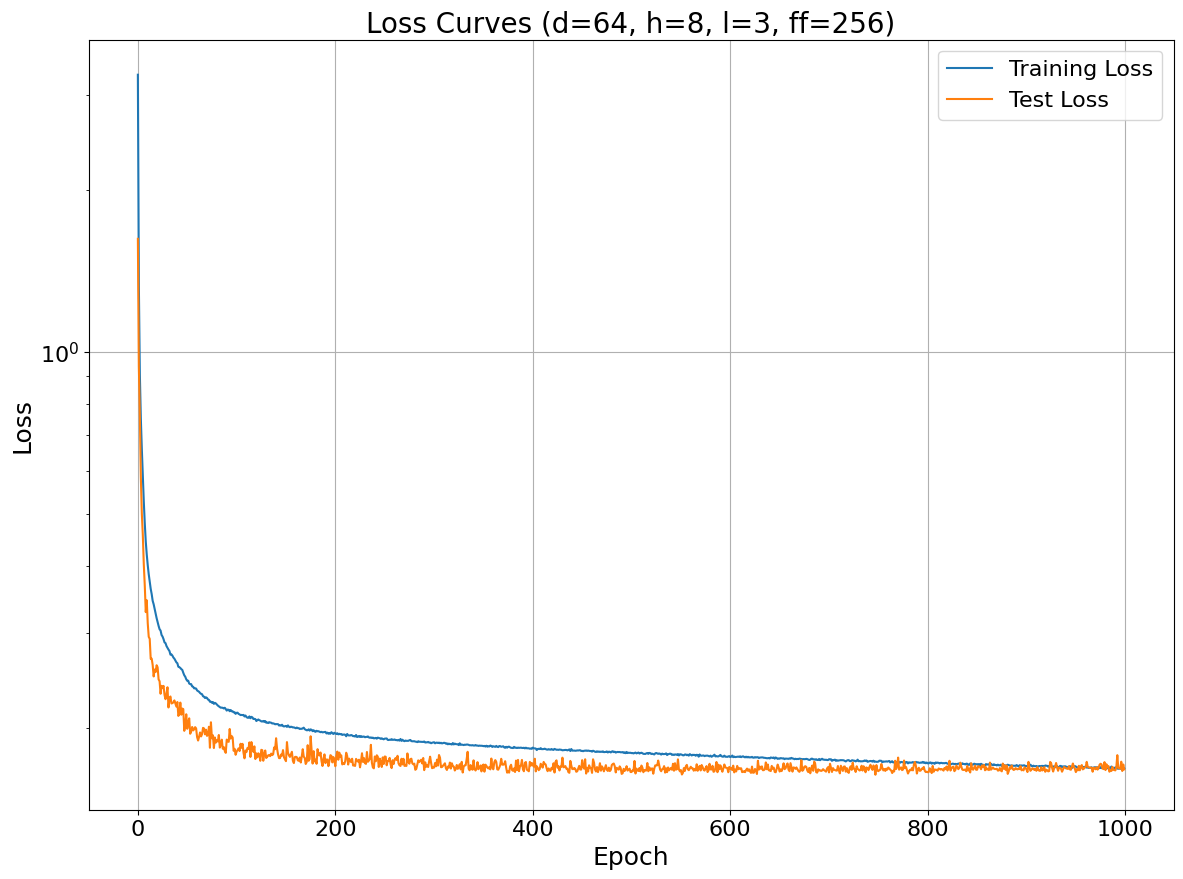

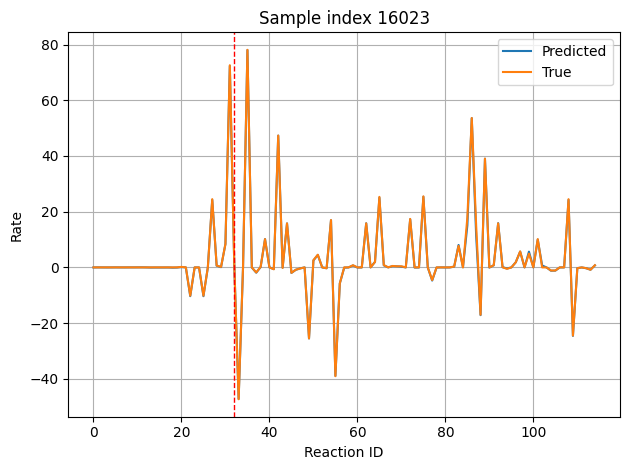

y_pred_outputs.shape: (39227, 95) min/max: -80.59187 109.5993
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.019500822 to 2.5737603


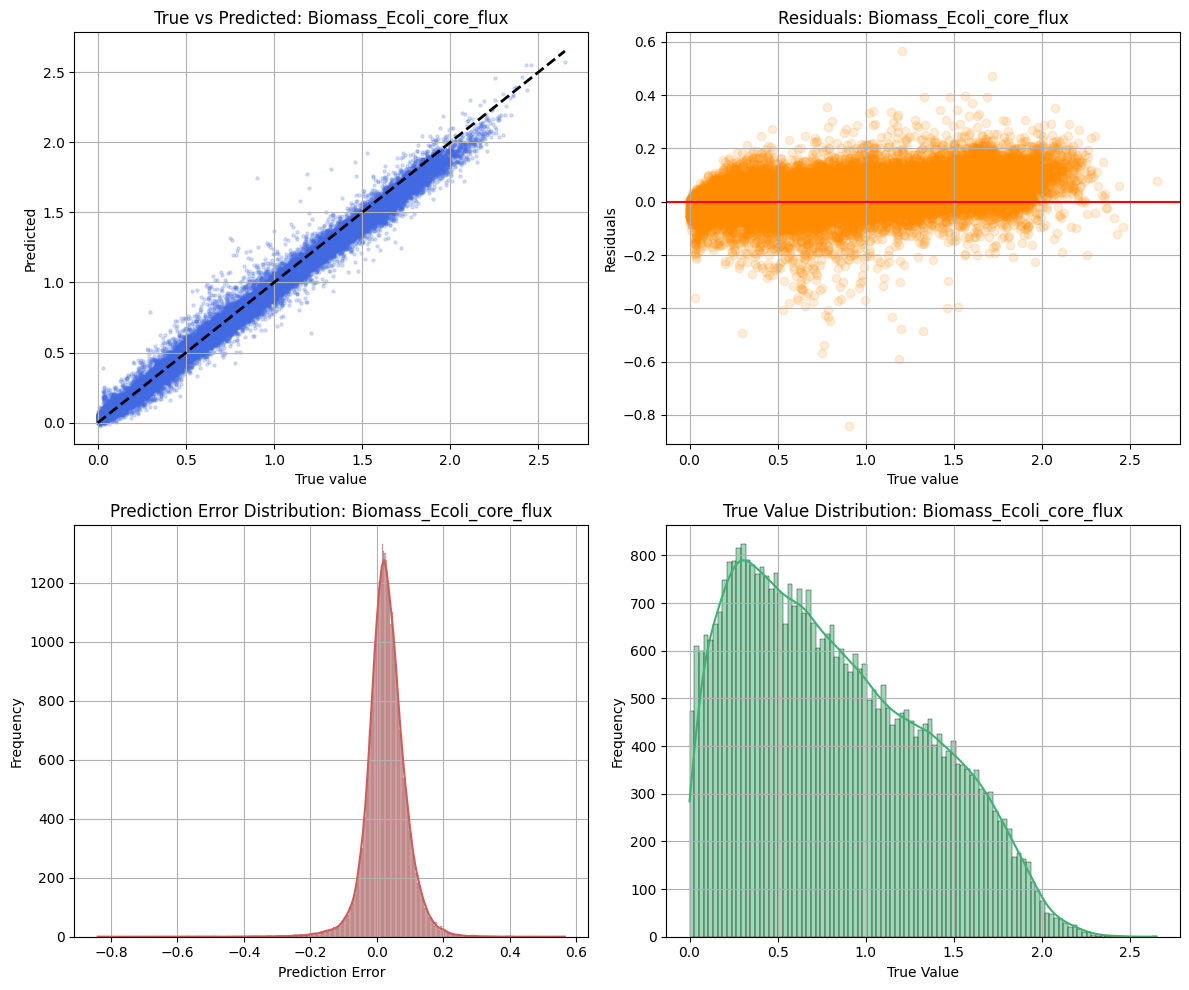

y_pred_outputs.shape: (39227, 95) min/max: -80.59187 109.5993
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -10.165756 to 24.637274


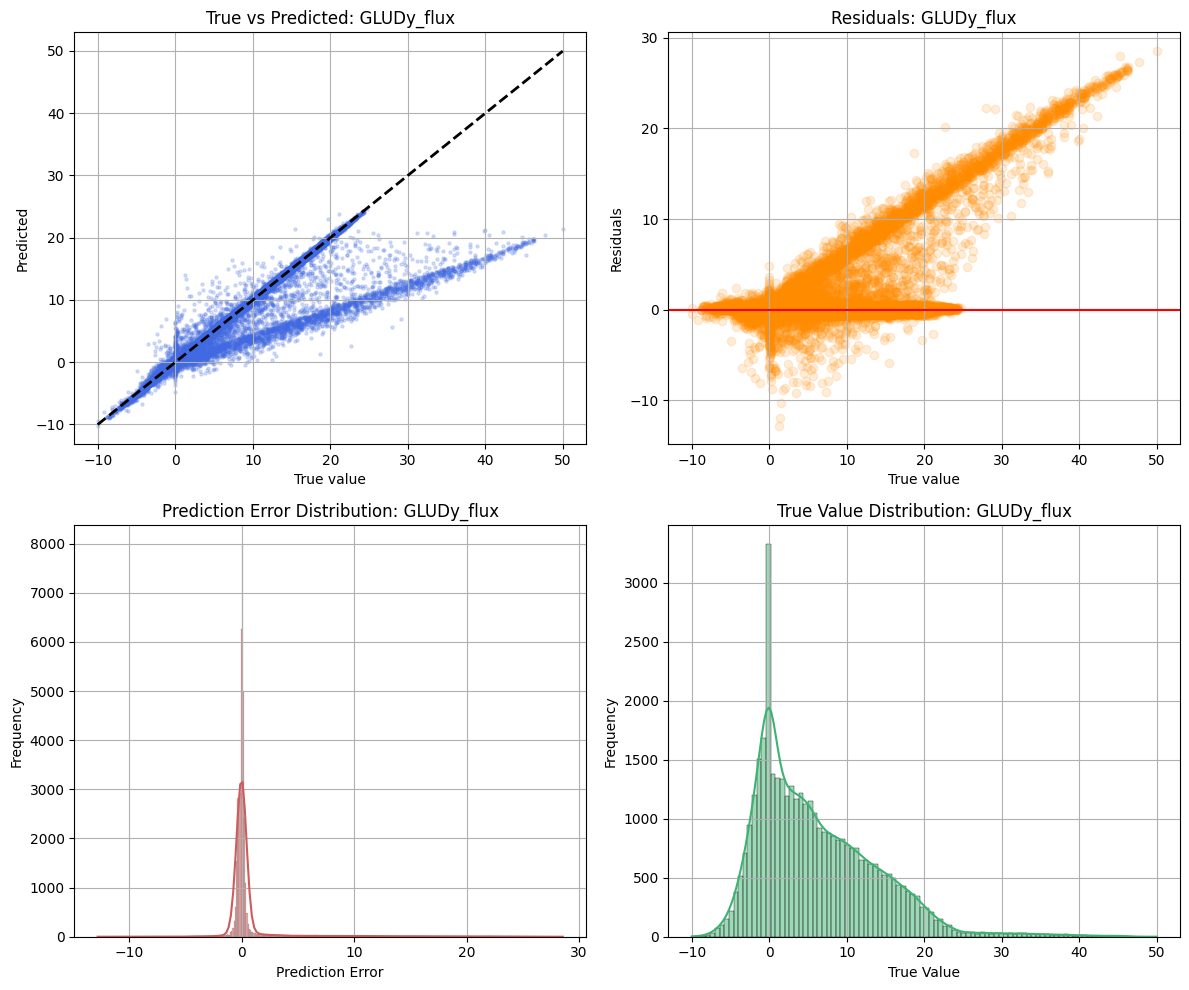

Number of parameters:
158857


In [30]:
train_losses_6483_256, test_losses_6483_256, model_6483_256 = train_model(d_model=64, n_heads=8, n_layers=3, d_ff=256, num_epochs=epochs, dropout=dropout)

plot_loss_curves(train_losses_6483_256, test_losses_6483_256, d_model=64, n_heads=8, n_layers=3, d_ff=256)

plot_prediction_sample(X_test, y_test, model_6483_256)

for flux_name in diagnostics_to_plot:
    plot_flux(model_6483_256, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_6483_256.parameters() if p.requires_grad ))

Epoch 100/500 | Train Loss: 0.201720 | Test Loss: 0.181065
Epoch 200/500 | Train Loss: 0.183910 | Test Loss: 0.171046
Epoch 300/500 | Train Loss: 0.176585 | Test Loss: 0.168641
Epoch 400/500 | Train Loss: 0.171358 | Test Loss: 0.167904
Epoch 500/500 | Train Loss: 0.167394 | Test Loss: 0.166391
Training Completed.
Training took 229 min 8.9 sec.


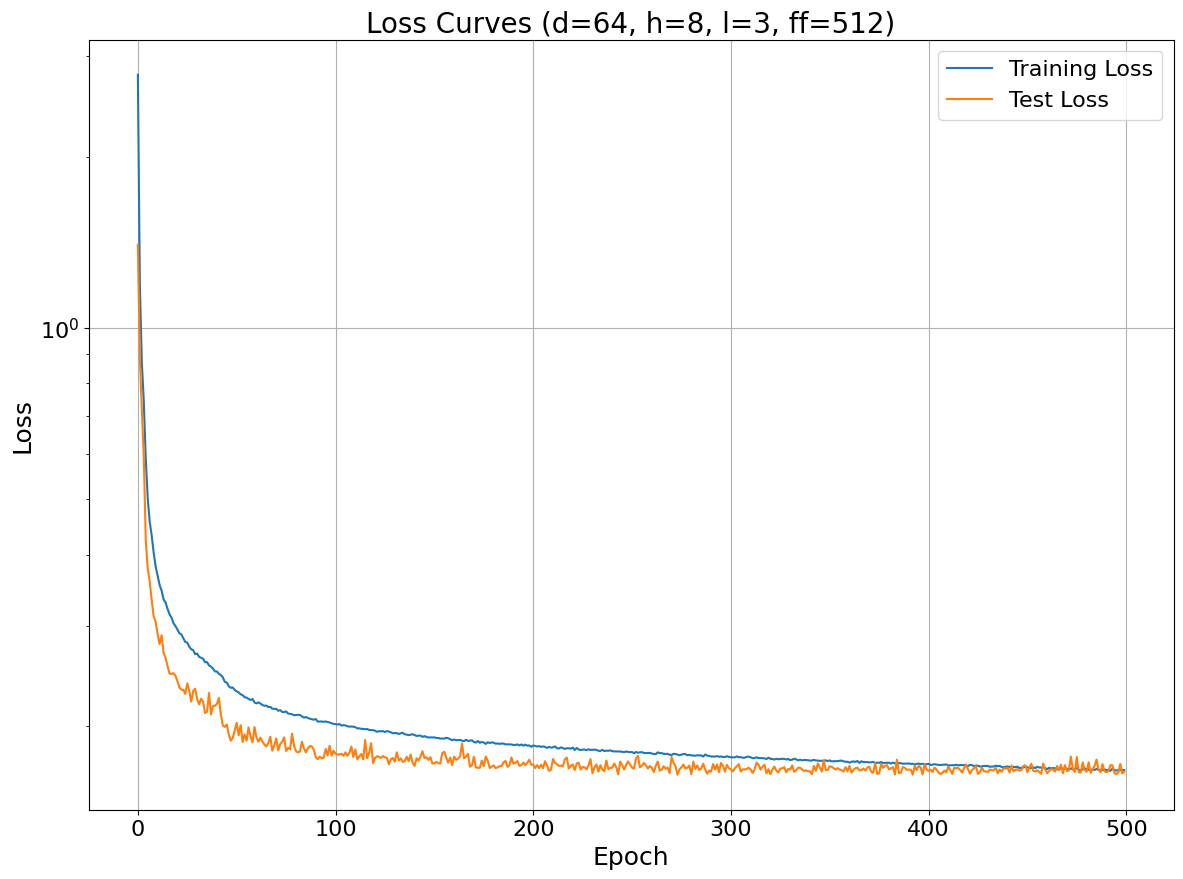

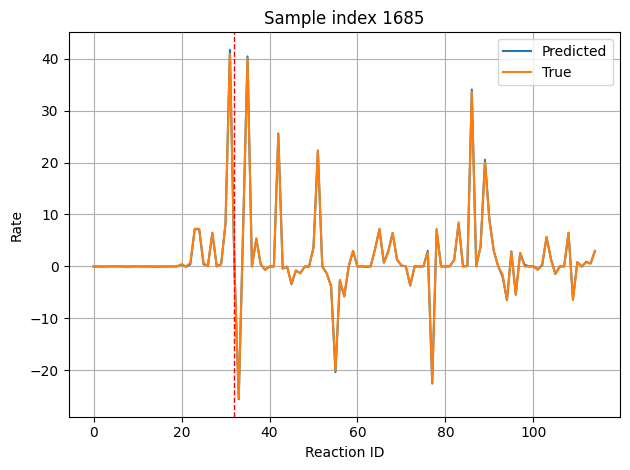

y_pred_outputs.shape: (39227, 95) min/max: -80.17691 108.33226
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.15869594 to 2.7278833


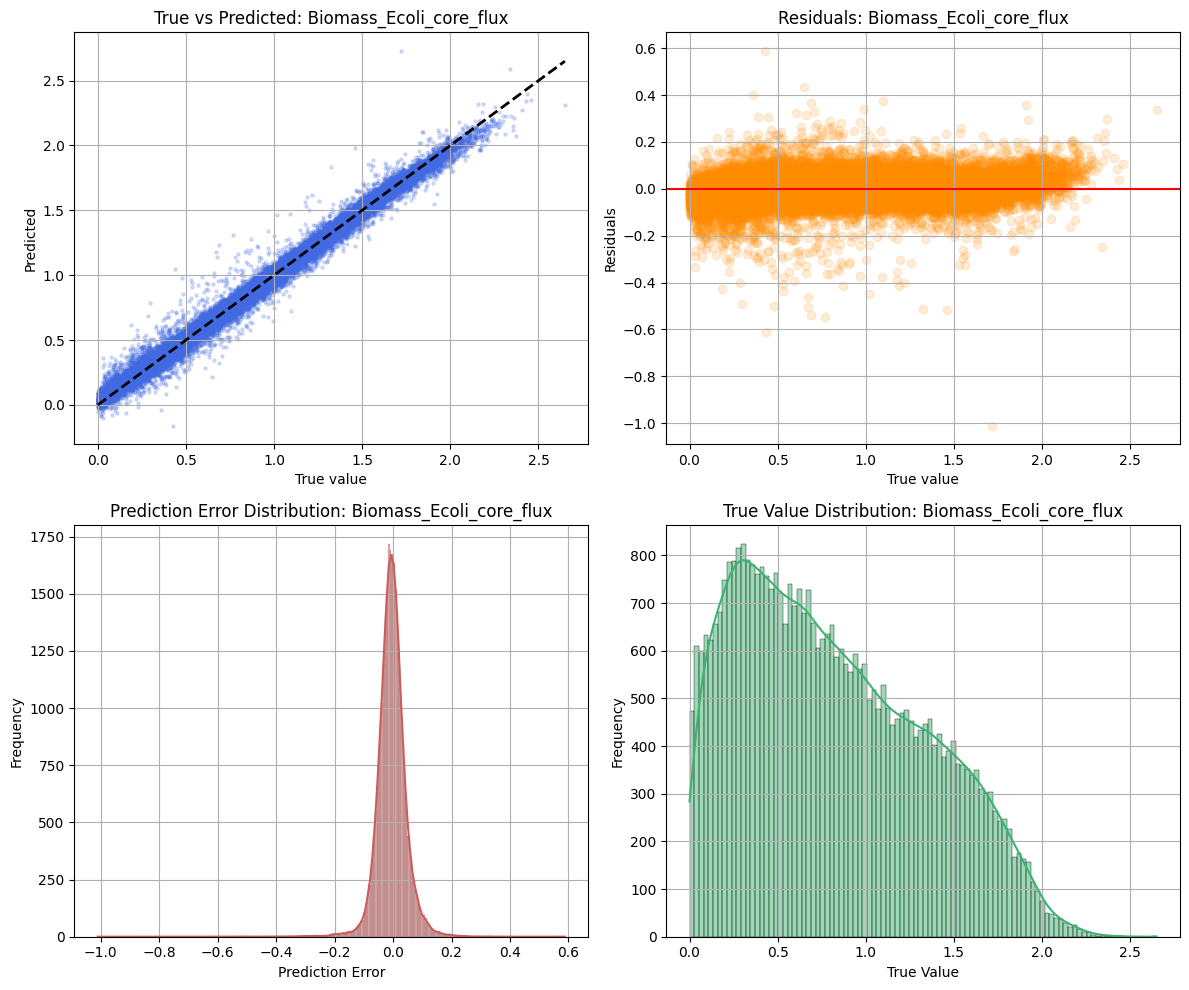

y_pred_outputs.shape: (39227, 95) min/max: -80.17691 108.33226
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -10.48575 to 25.05043


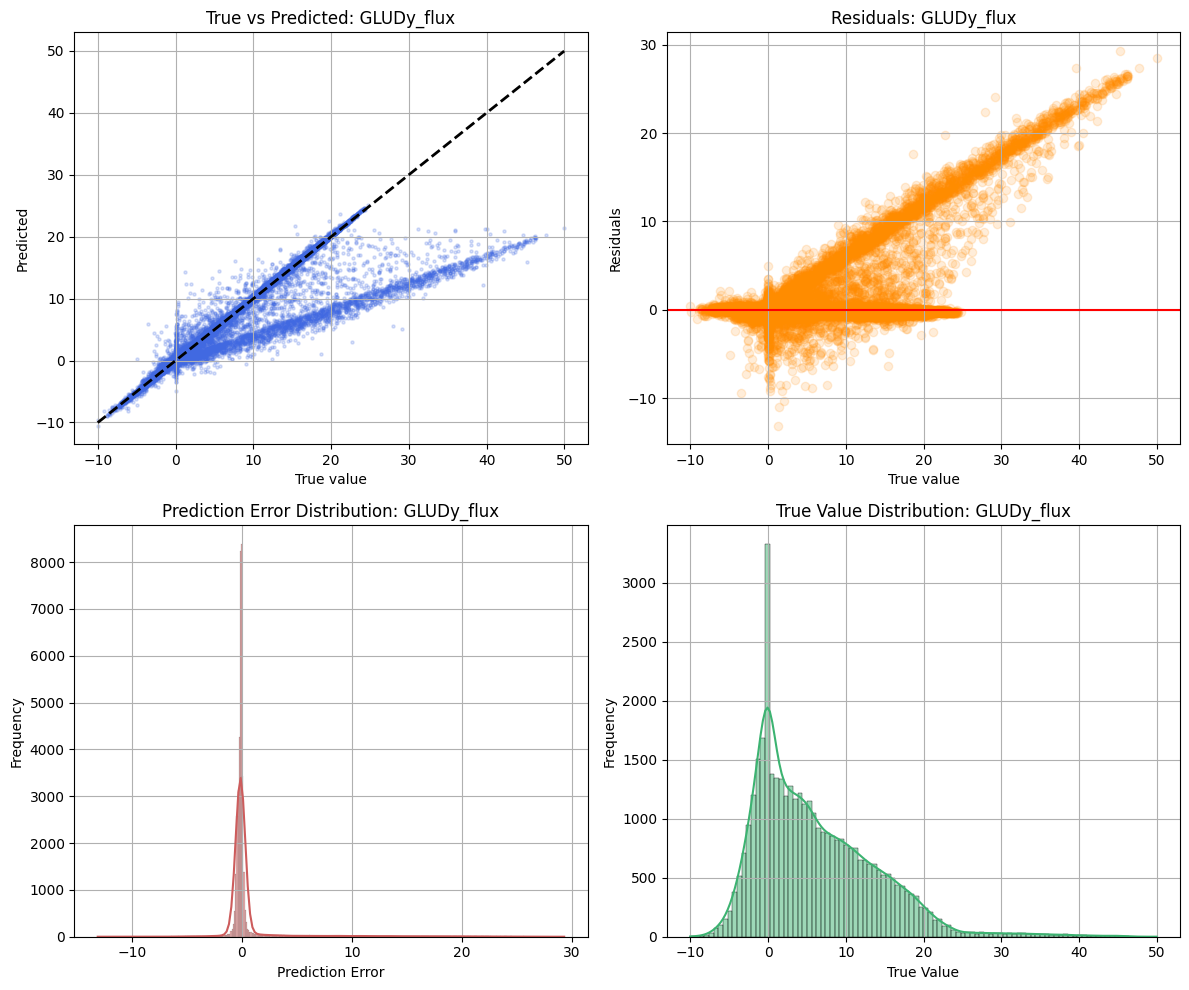

Number of parameters:
259465


In [31]:
epochs = 500

train_losses_6483_512, test_losses_6483_512, model_6483_512 = train_model(d_model=64, n_heads=8, n_layers=3, d_ff=512, num_epochs=epochs, dropout=dropout)

plot_loss_curves(train_losses_6483_512, test_losses_6483_512, d_model=64, n_heads=8, n_layers=3, d_ff=512)

plot_prediction_sample(X_test, y_test, model_6483_512)

for flux_name in diagnostics_to_plot:
    plot_flux(model_6483_512, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_6483_512.parameters() if p.requires_grad ))

Epoch 100/500 | Train Loss: 0.244776 | Test Loss: 0.212912
Epoch 200/500 | Train Loss: 0.221598 | Test Loss: 0.200787
Epoch 300/500 | Train Loss: 0.211879 | Test Loss: 0.199088
Epoch 400/500 | Train Loss: 0.207057 | Test Loss: 0.190066
Epoch 500/500 | Train Loss: 0.204052 | Test Loss: 0.187990
Training Completed.
Training took 160 min 57.9 sec.


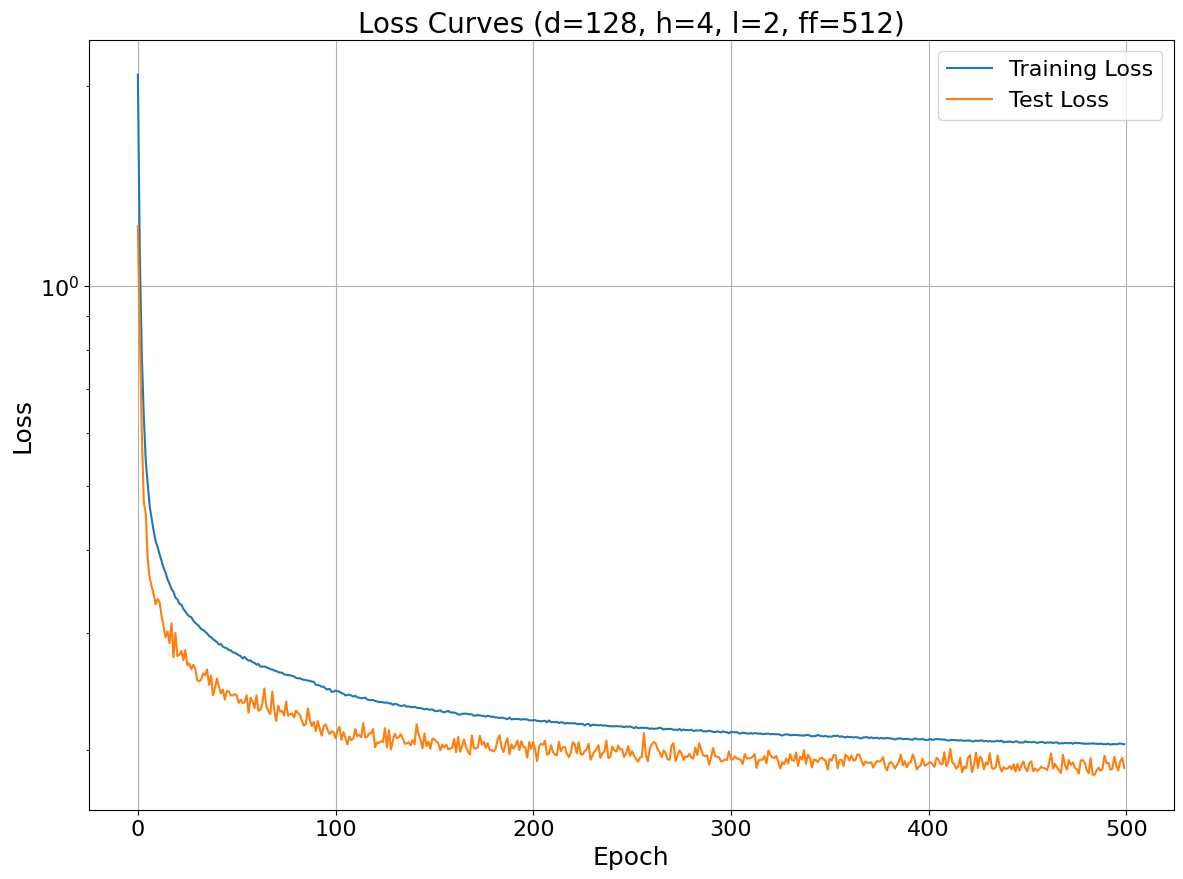

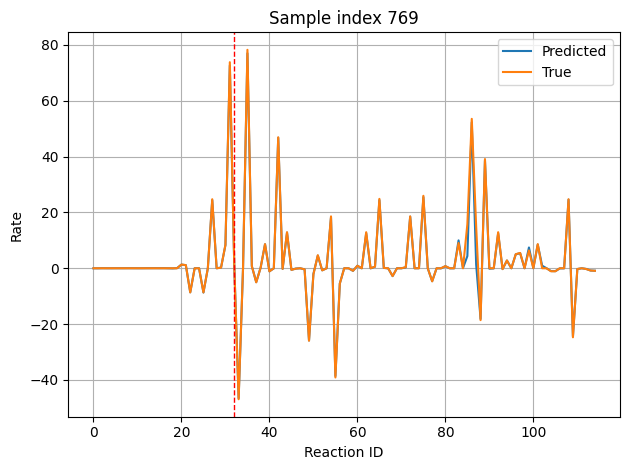

y_pred_outputs.shape: (39227, 95) min/max: -79.67752 108.16591
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.043269306 to 2.3471527


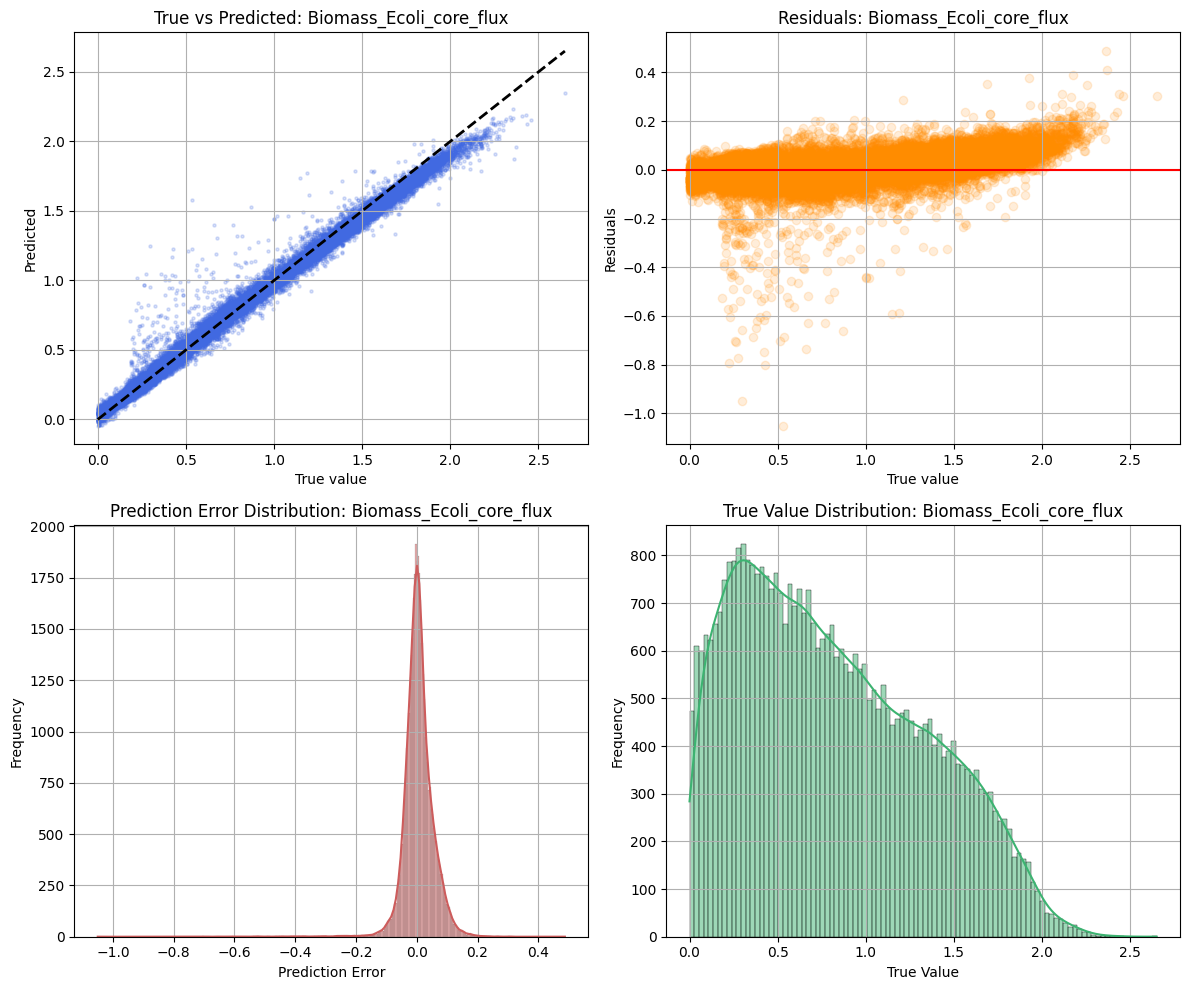

y_pred_outputs.shape: (39227, 95) min/max: -79.67752 108.16591
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -9.525812 to 24.518589


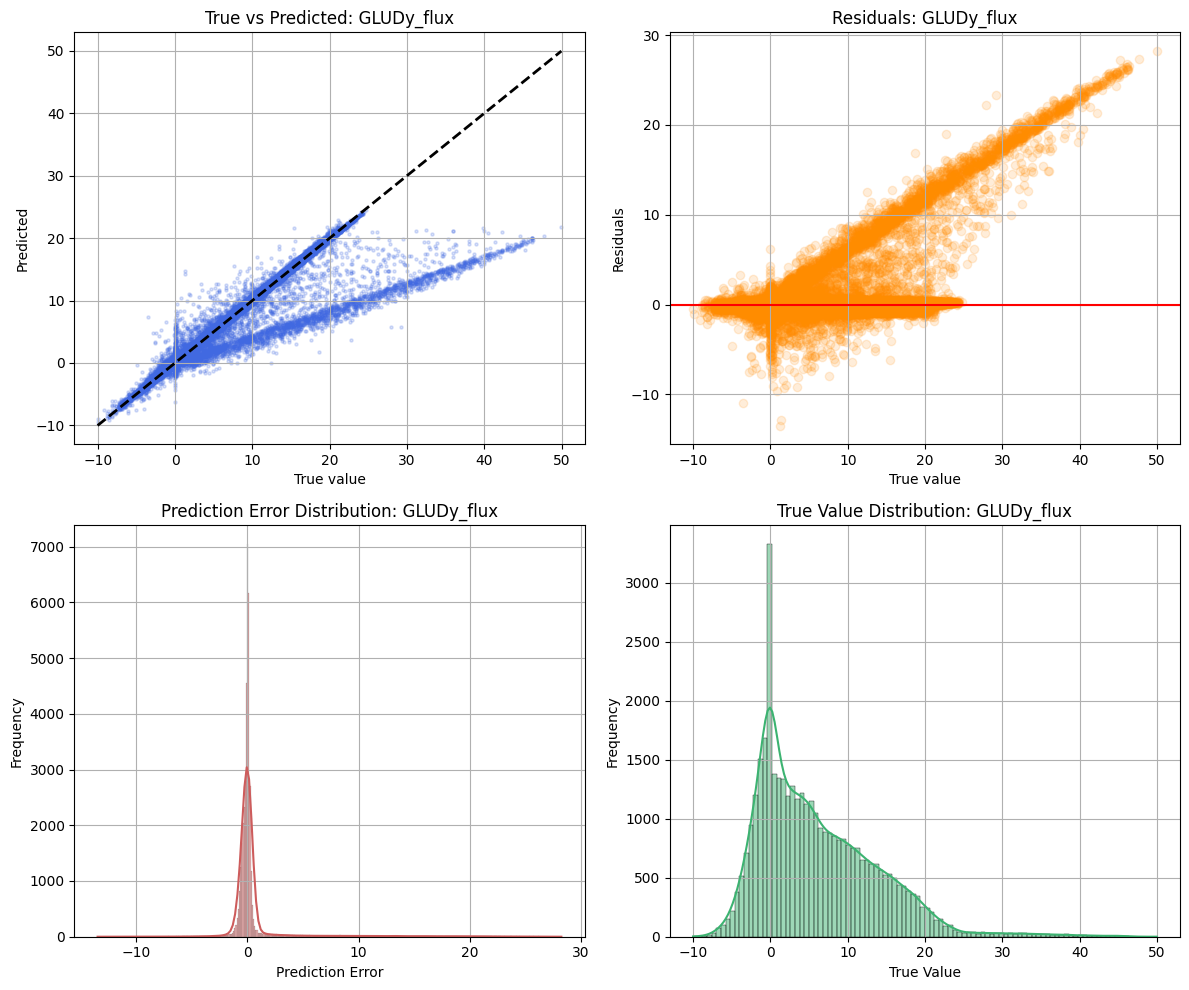

Number of parameters:
413318


In [32]:
epochs = 500

train_losses_12842_512, test_losses_12842_512, model_12842_512 = train_model(d_model=128, n_heads=4, n_layers=2, d_ff=512, num_epochs=epochs, dropout=dropout)

plot_loss_curves(train_losses_12842_512, test_losses_12842_512, d_model=128, n_heads=4, n_layers=2, d_ff=512)

plot_prediction_sample(X_test, y_test, model_12842_512)

for flux_name in diagnostics_to_plot:
    plot_flux(model_12842_512, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_12842_512.parameters() if p.requires_grad ))

Epoch 100/500 | Train Loss: 0.188283 | Test Loss: 0.177298
Epoch 200/500 | Train Loss: 0.171005 | Test Loss: 0.177829
Epoch 300/500 | Train Loss: 0.160955 | Test Loss: 0.169988
Epoch 400/500 | Train Loss: 0.151007 | Test Loss: 0.173538
Epoch 500/500 | Train Loss: 0.140838 | Test Loss: 0.184860
Training Completed.
Training took 233 min 8.8 sec.


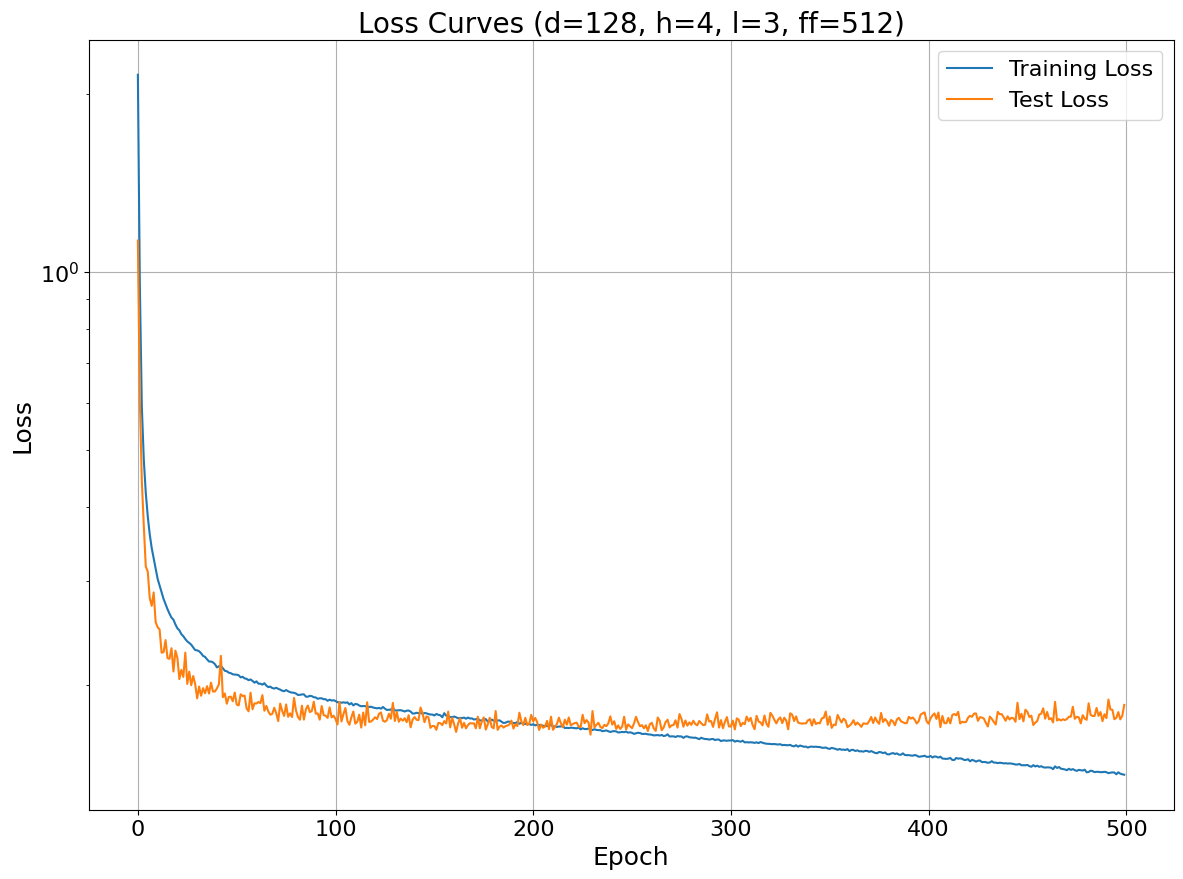

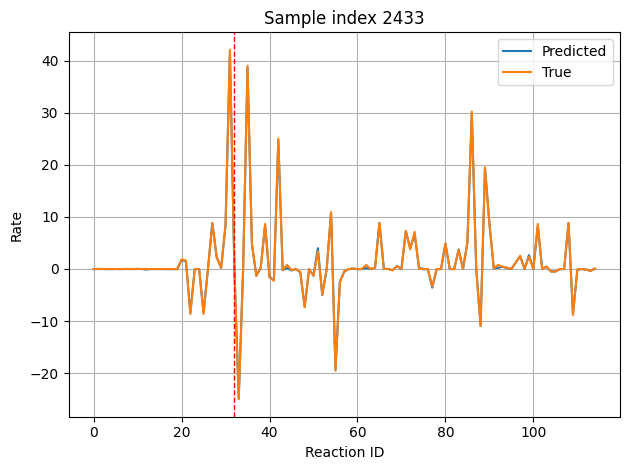

y_pred_outputs.shape: (39227, 95) min/max: -78.68764 107.85871
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.15875459 to 2.4494643


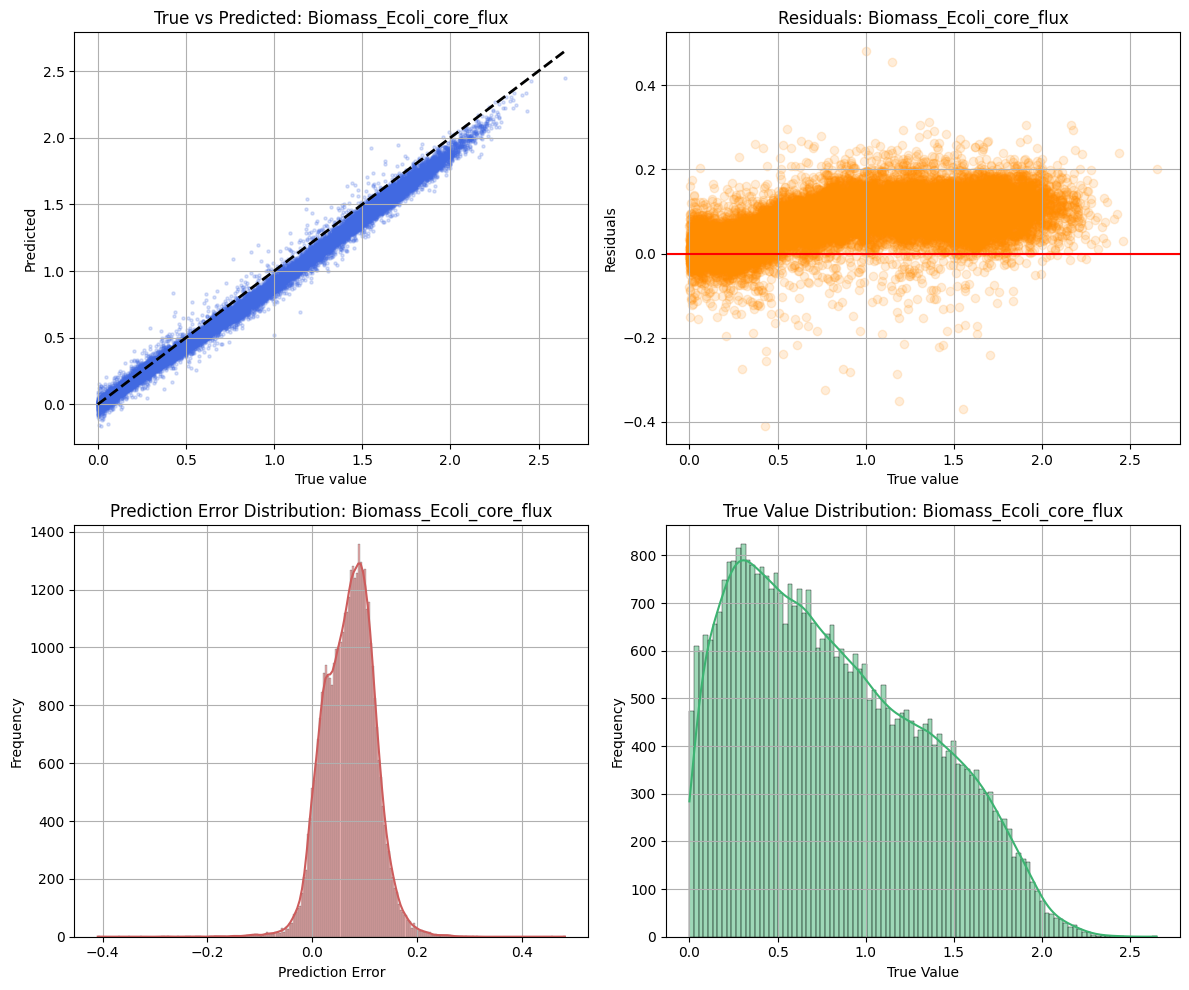

y_pred_outputs.shape: (39227, 95) min/max: -78.68764 107.85871
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -10.21483 to 23.887085


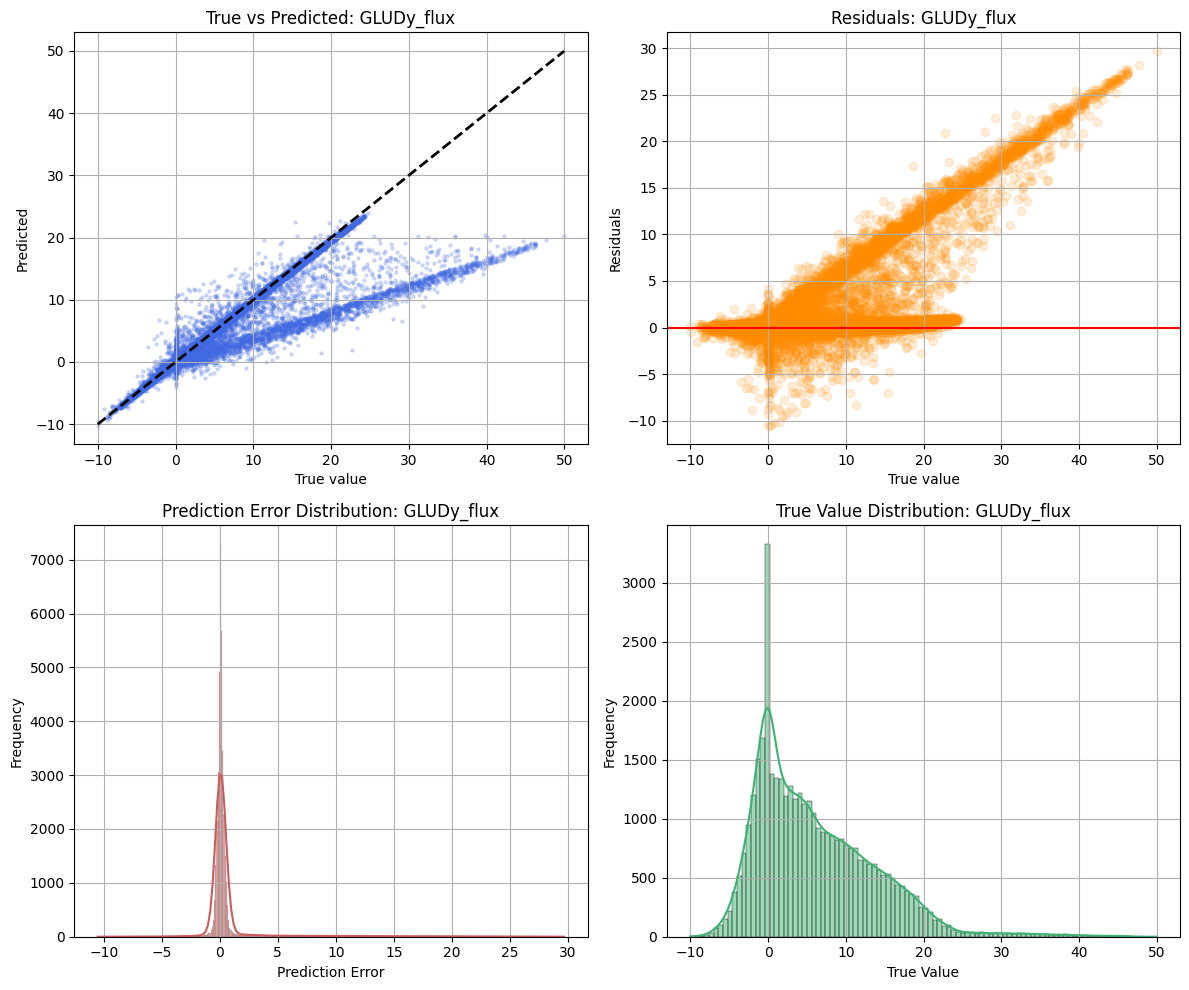

Number of parameters:
612617


In [33]:
epochs = 500

train_losses_12843_512, test_losses_12843_512, model_12843_512 = train_model(d_model=128, n_heads=4, n_layers=3, d_ff=512, num_epochs=epochs, dropout=dropout)

plot_loss_curves(train_losses_12843_512, test_losses_12843_512, d_model=128, n_heads=4, n_layers=3, d_ff=512)

plot_prediction_sample(X_test, y_test, model_12843_512)

for flux_name in diagnostics_to_plot:
    plot_flux(model_12843_512, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_12843_512.parameters() if p.requires_grad ))

Epoch 100/500 | Train Loss: 0.180156 | Test Loss: 0.167288
Epoch 200/500 | Train Loss: 0.164724 | Test Loss: 0.169035
Epoch 300/500 | Train Loss: 0.152843 | Test Loss: 0.171095
Epoch 400/500 | Train Loss: 0.139092 | Test Loss: 0.172981
Epoch 500/500 | Train Loss: 0.126593 | Test Loss: 0.175534
Training Completed.
Training took 325 min 10.2 sec.


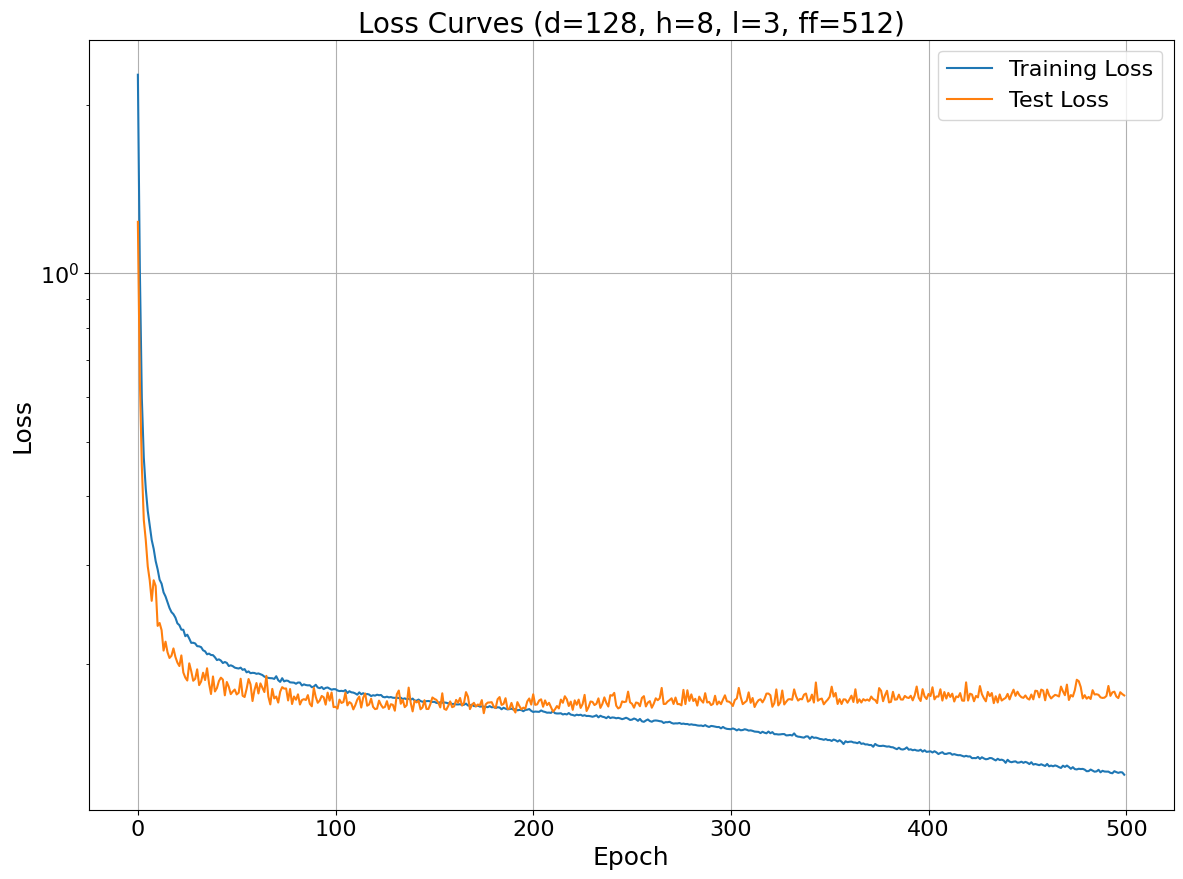

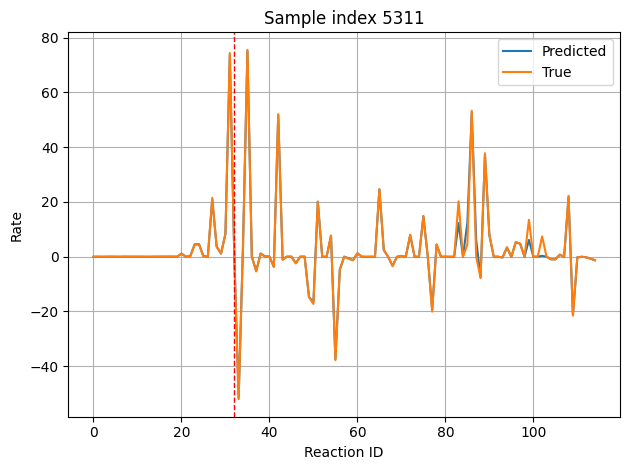

y_pred_outputs.shape: (39227, 95) min/max: -79.50819 109.422485
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.058699846 to 2.372433


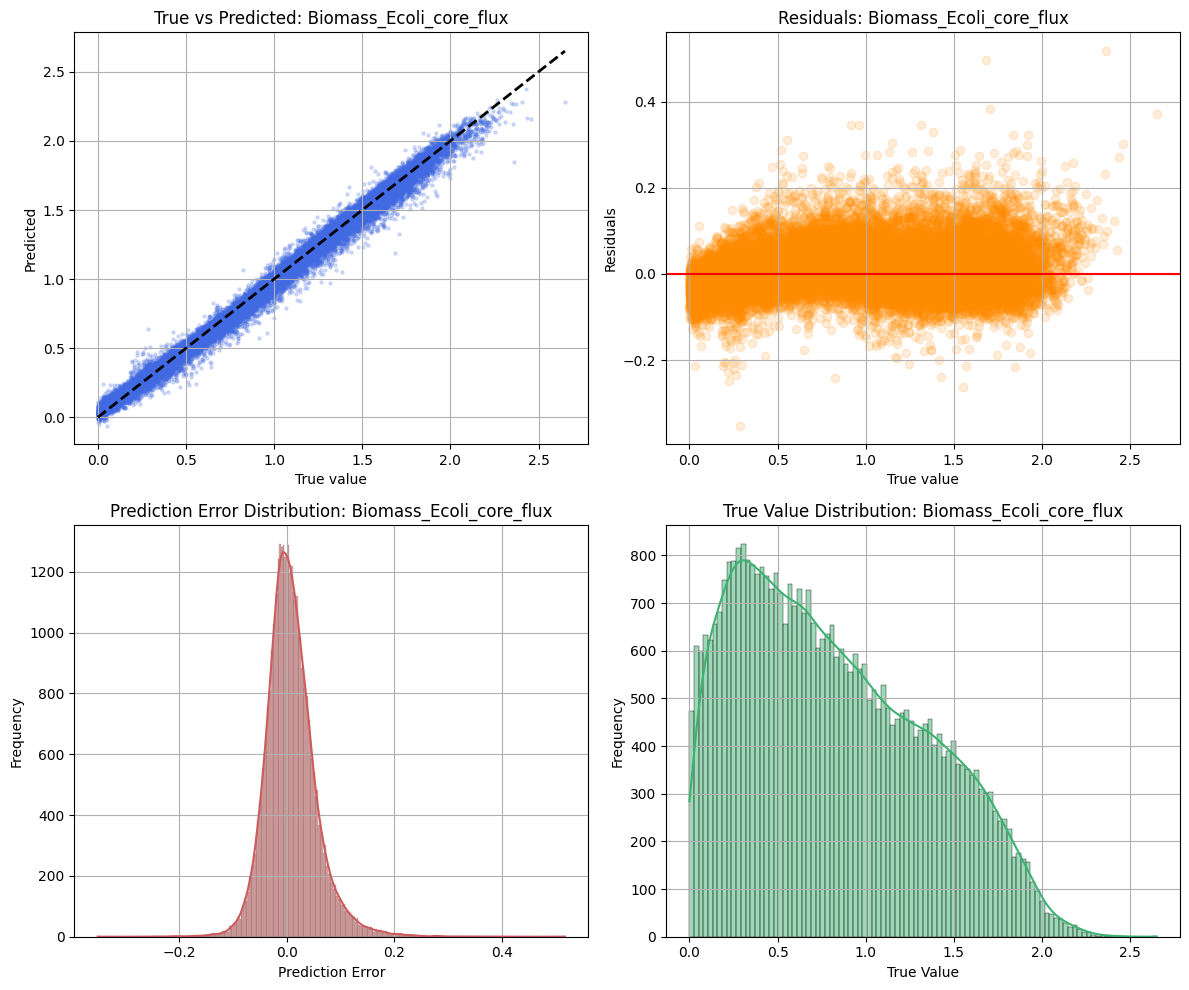

y_pred_outputs.shape: (39227, 95) min/max: -79.50819 109.422485
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -10.210188 to 24.87946


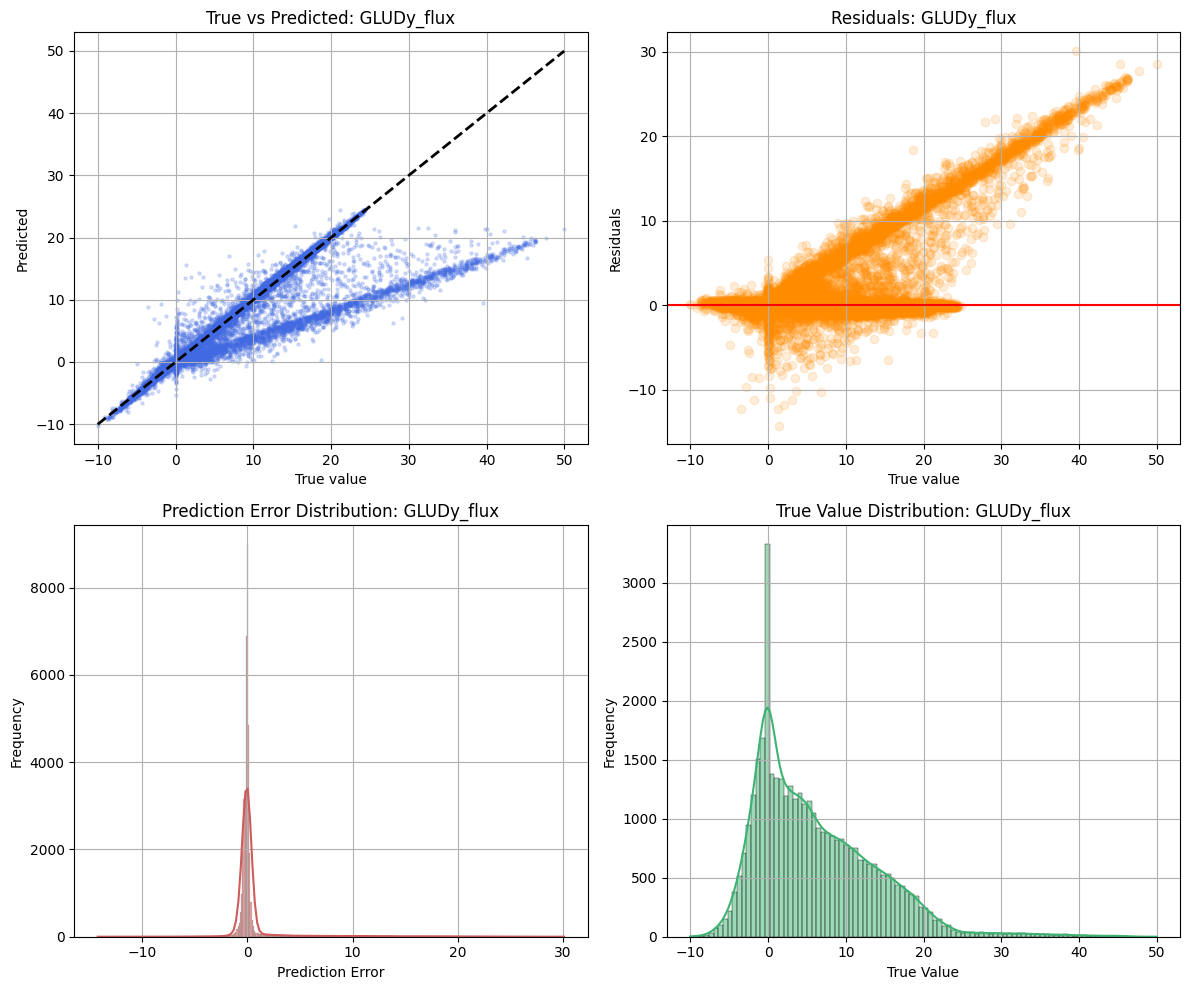

Number of parameters:
612617


In [34]:
epochs = 500

train_losses_12883_512, test_losses_12883_512, model_12883_512 = train_model(d_model=128, n_heads=8, n_layers=3, d_ff=512, num_epochs=epochs, dropout=dropout)

plot_loss_curves(train_losses_12883_512, test_losses_12883_512, d_model=128, n_heads=8, n_layers=3, d_ff=512)

plot_prediction_sample(X_test, y_test, model_12883_512)

for flux_name in diagnostics_to_plot:
    plot_flux(model_12883_512, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_12883_512.parameters() if p.requires_grad ))